In [1]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
vijayaadithyanvg_car_price_predictionused_cars_path = kagglehub.dataset_download('vijayaadithyanvg/car-price-predictionused-cars')

print('Data source import complete.')


Using Colab cache for faster access to the 'car-price-predictionused-cars' dataset.
Data source import complete.


In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/car-price-predictionused-cars/car data.csv


In [3]:
# ============================================
# TASK 3: CAR PRICE PREDICTION WITH MACHINE LEARNING
# ============================================
# OASIS INFOBYTE - DATA SCIENCE INTERNSHIP
# Author: Your Name
# Dataset: Car Price Prediction Dataset
# ============================================

INSTALLATION & SETUP

In [4]:
# --------------------------------------------
# BLOCK 1: INSTALL REQUIRED PACKAGES
# --------------------------------------------

!pip install -q xgboost lightgbm catboost optuna shap phik pandas-profiling
!pip install -q scikit-learn pandas numpy matplotlib seaborn

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 87.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 36.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 39.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 262.6/262.6 kB 19.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 114.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.4/102.4 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 309.8/309.8 kB 30.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 29.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are install

In [5]:
pip install --upgrade scikit-learn joblib

  Using cached scikit_learn-1.8.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (11 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 29.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 309.1/309.1 kB 10.1 MB/s eta 0:00:00
  Attempting uninstall: joblib
    Found existing installation: joblib 1.1.1
    Uninstalling joblib-1.1.1:
      Successfully uninstalled joblib-1.1.1
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.3.0
    Uninstalling scikit-learn-1.3.0:
      Successfully uninstalled scikit-learn-1.3.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pandas-profiling 3.2.0 requires joblib~=1.1.0, but you have joblib 1.5.3 which is incompatible.


IMPORT LIBRARIES

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time
import joblib
import os
import re
from datetime import datetime

# Suppress warnings
warnings.filterwarnings('ignore')

# Advanced visualization
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Machine Learning
from sklearn.model_selection import (train_test_split, cross_val_score,
                                    GridSearchCV, RandomizedSearchCV, KFold)
from sklearn.preprocessing import (StandardScaler, MinMaxScaler,
                                 LabelEncoder, OneHotEncoder)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (mean_squared_error, mean_absolute_error,
                           r2_score, mean_absolute_percentage_error)

# Feature Selection
from sklearn.feature_selection import SelectKBest, f_regression, mutual_info_regression

# ML Models
from sklearn.linear_model import (LinearRegression, Ridge, Lasso,
                                 ElasticNet, BayesianRidge)
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (RandomForestRegressor, GradientBoostingRegressor,
                            AdaBoostRegressor, ExtraTreesRegressor,
                            StackingRegressor, VotingRegressor)
from sklearn.svm import SVR
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

# Hyperparameter Optimization
import optuna

# Advanced evaluation
from scipy import stats
from sklearn.model_selection import learning_curve

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


LOAD AND EXPLORE DATA

In [7]:
print("="*60)
print("STEP 1: LOADING DATASET")
print("="*60)

# Load the dataset with your correct path
file_path = '/kaggle/input/car-price-predictionused-cars/car data.csv'

try:
    df = pd.read_csv(file_path)
    print("✅ Dataset loaded successfully from Kaggle path")
except:
    df = pd.read_csv('car data.csv')
    print("✅ Dataset loaded from local path")

print(f"\n📊 Original Dataset Shape: {df.shape}")
print(f"\n📋 Original Column Names: {df.columns.tolist()}")

# Rename columns to match our code
df = df.rename(columns={
    'Selling_Price': 'price',
    'Present_Price': 'present_price',
    'Driven_kms': 'driven_kms',
    'Fuel_Type': 'fuel_type',
    'Selling_type': 'selling_type',
    'Transmission': 'transmission',
    'Car_Name': 'CarName'
})

print(f"\n Renamed columns:")
print(f"   Selling_Price → price")
print(f"   Present_Price → present_price")
print(f"   Driven_kms → driven_kms")
print(f"   Fuel_Type → fuel_type")
print(f"   Selling_type → selling_type")
print(f"   Transmission → transmission")
print(f"   Car_Name → CarName")

print(f"\n📋 Final Column Names: {df.columns.tolist()}")
print(f"\n📋 First 5 rows:")
print(df.head())

print(f"\n📊 Data Types:")
print(df.dtypes)

STEP 1: LOADING DATASET
✅ Dataset loaded successfully from Kaggle path

📊 Original Dataset Shape: (301, 9)

📋 Original Column Names: ['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Driven_kms', 'Fuel_Type', 'Selling_type', 'Transmission', 'Owner']

 Renamed columns:
   Selling_Price → price
   Present_Price → present_price
   Driven_kms → driven_kms
   Fuel_Type → fuel_type
   Selling_type → selling_type
   Transmission → transmission
   Car_Name → CarName

📋 Final Column Names: ['CarName', 'Year', 'price', 'present_price', 'driven_kms', 'fuel_type', 'selling_type', 'transmission', 'Owner']

📋 First 5 rows:
   CarName  Year  price  present_price  driven_kms fuel_type selling_type  \
0     ritz  2014   3.35           5.59       27000    Petrol       Dealer   
1      sx4  2013   4.75           9.54       43000    Diesel       Dealer   
2     ciaz  2017   7.25           9.85        6900    Petrol       Dealer   
3  wagon r  2011   2.85           4.15        5200    Petrol       De

DATA PREPROCESSING

STEP 2: DATA PREPROCESSING

🔍 Missing Values:
CarName          0
Year             0
price            0
present_price    0
driven_kms       0
fuel_type        0
selling_type     0
transmission     0
Owner            0
dtype: int64

🔍 Duplicates: 2
✅ Removed 2 duplicates

📊 Dataset Info:
   - Total samples: 299
   - Features: 9
   - Memory usage: 0.02 MB

📊 Statistical Summary:
              Year       price  present_price     driven_kms       Owner
count   299.000000  299.000000     299.000000     299.000000  299.000000
mean   2013.615385    4.589632       7.541037   36916.752508    0.043478
std       2.896868    4.984240       8.566332   39015.170352    0.248720
min    2003.000000    0.100000       0.320000     500.000000    0.000000
25%    2012.000000    0.850000       1.200000   15000.000000    0.000000
50%    2014.000000    3.510000       6.100000   32000.000000    0.000000
75%    2016.000000    6.000000       9.840000   48883.500000    0.000000
max    2018.000000   35.000000      9

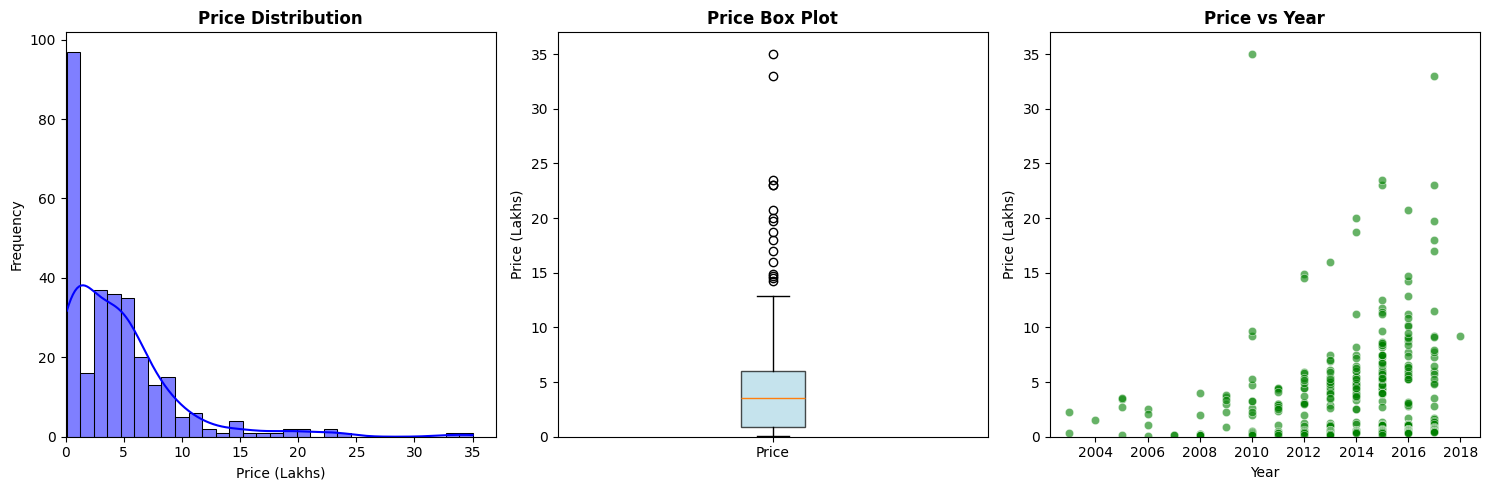


📊 Price Statistics:
   - Min Price: ₹0.10 Lakhs
   - Max Price: ₹35.00 Lakhs
   - Mean Price: ₹4.59 Lakhs
   - Median Price: ₹3.51 Lakhs
   - Q1: ₹0.85 Lakhs
   - Q3: ₹6.00 Lakhs
   - IQR: ₹5.15 Lakhs
   - Outliers: 16 (5.35%)


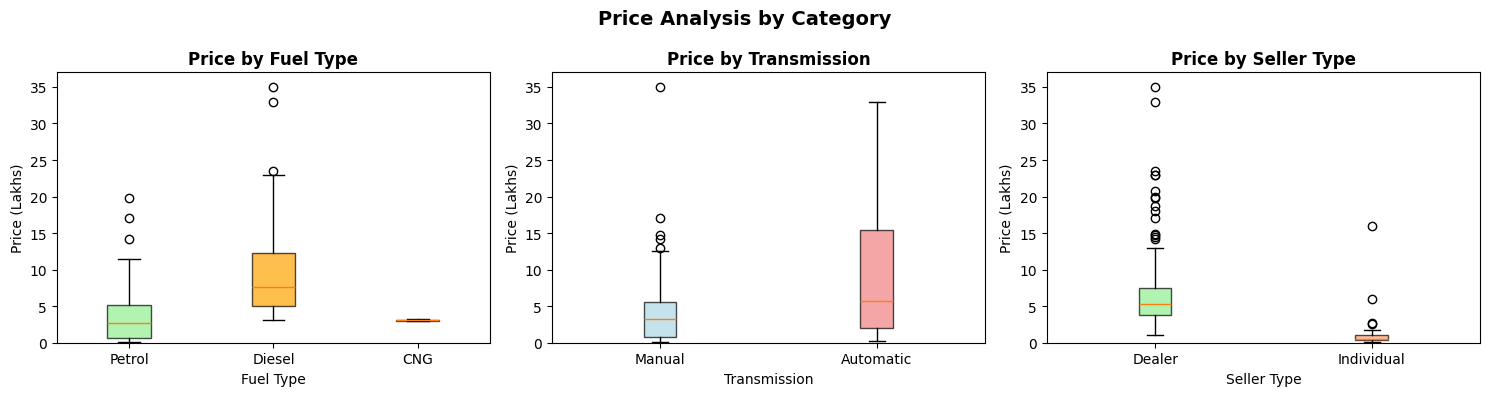


✅ Data preprocessing completed successfully!


In [ ]:
print("="*60)
print("STEP 2: DATA PREPROCESSING")
print("="*60)

# Create a copy
df_clean = df.copy()

# Check missing values
print("\n🔍 Missing Values:")
print(df_clean.isnull().sum())

# Check duplicates
duplicates = df_clean.duplicated().sum()
print(f"\n🔍 Duplicates: {duplicates}")
if duplicates > 0:
    df_clean = df_clean.drop_duplicates()
    print(f"✅ Removed {duplicates} duplicates")

# Basic info
print(f"\n📊 Dataset Info:")
print(f"   - Total samples: {len(df_clean)}")
print(f"   - Features: {df_clean.shape[1]}")
print(f"   - Memory usage: {df_clean.memory_usage().sum() / 1024**2:.2f} MB")

# Statistical summary
print("\n📊 Statistical Summary:")
print(df_clean.describe())

# Check unique values in categorical columns
print("\n📊 Categorical Columns Unique Values:")
categorical_cols = df_clean.select_dtypes(include=['object']).columns
for col in categorical_cols:
    print(f"   {col}: {df_clean[col].nunique()} unique values")
    print(f"      Values: {df_clean[col].unique()[:5]}...")

# FIXED: Price Distribution with proper scaling (using 'price' column)
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.histplot(df_clean['price'], bins=30, kde=True, color='blue')
plt.title('Price Distribution', fontweight='bold', fontsize=12)
plt.xlabel('Price (Lakhs)')
plt.ylabel('Frequency')
# Set proper x-axis limits
plt.xlim(0, df_clean['price'].max() + 2)

plt.subplot(1, 3, 2)
# FIXED: Box plot with proper scaling (using 'price')
box_data = [df_clean['price']]
bp = plt.boxplot(box_data, patch_artist=True)
bp['boxes'][0].set_facecolor('lightblue')
bp['boxes'][0].set_alpha(0.7)
plt.title('Price Box Plot', fontweight='bold', fontsize=12)
plt.ylabel('Price (Lakhs)')
plt.xticks([1], ['Price'])
# Set proper y-axis limits
plt.ylim(0, df_clean['price'].max() + 2)

plt.subplot(1, 3, 3)
sns.scatterplot(data=df_clean, x='Year', y='price', alpha=0.6, color='green')
plt.title('Price vs Year', fontweight='bold', fontsize=12)
plt.xlabel('Year')
plt.ylabel('Price (Lakhs)')
# Set proper y-axis limits
plt.ylim(0, df_clean['price'].max() + 2)

plt.tight_layout()
plt.show()

# Check for price outliers using IQR (using 'price')
Q1 = df_clean['price'].quantile(0.25)
Q3 = df_clean['price'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df_clean[(df_clean['price'] < lower_bound) | (df_clean['price'] > upper_bound)]
print(f"\n📊 Price Statistics:")
print(f"   - Min Price: ₹{df_clean['price'].min():.2f} Lakhs")
print(f"   - Max Price: ₹{df_clean['price'].max():.2f} Lakhs")
print(f"   - Mean Price: ₹{df_clean['price'].mean():.2f} Lakhs")
print(f"   - Median Price: ₹{df_clean['price'].median():.2f} Lakhs")
print(f"   - Q1: ₹{Q1:.2f} Lakhs")
print(f"   - Q3: ₹{Q3:.2f} Lakhs")
print(f"   - IQR: ₹{IQR:.2f} Lakhs")
print(f"   - Outliers: {len(outliers)} ({len(outliers)/len(df_clean)*100:.2f}%)")

# FIXED: Price by Fuel Type - using 'price'
plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
# Get data for each fuel type
fuel_types = df_clean['fuel_type'].unique()
data_to_plot = [df_clean[df_clean['fuel_type'] == ft]['price'].values for ft in fuel_types]
bp1 = plt.boxplot(data_to_plot, labels=fuel_types, patch_artist=True)
# Color the boxes
colors = ['lightgreen', 'orange', 'lightblue']
for patch, color in zip(bp1['boxes'], colors[:len(fuel_types)]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
plt.title('Price by Fuel Type', fontweight='bold', fontsize=12)
plt.xlabel('Fuel Type')
plt.ylabel('Price (Lakhs)')
plt.ylim(0, df_clean['price'].max() + 2)  # FIXED: Set y-axis limits

plt.subplot(1, 3, 2)
# Price by Transmission (using 'transmission')
trans_types = df_clean['transmission'].unique()
data_to_plot = [df_clean[df_clean['transmission'] == tt]['price'].values for tt in trans_types]
bp2 = plt.boxplot(data_to_plot, labels=trans_types, patch_artist=True)
for patch, color in zip(bp2['boxes'], ['lightblue', 'lightcoral']):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
plt.title('Price by Transmission', fontweight='bold', fontsize=12)
plt.xlabel('Transmission')
plt.ylabel('Price (Lakhs)')
plt.ylim(0, df_clean['price'].max() + 2)  # FIXED: Set y-axis limits

plt.subplot(1, 3, 3)
# Price by Seller Type (using 'selling_type')
seller_types = df_clean['selling_type'].unique()
data_to_plot = [df_clean[df_clean['selling_type'] == st]['price'].values for st in seller_types]
bp3 = plt.boxplot(data_to_plot, labels=seller_types, patch_artist=True)
for patch, color in zip(bp3['boxes'], ['lightgreen', 'lightsalmon']):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
plt.title('Price by Seller Type', fontweight='bold', fontsize=12)
plt.xlabel('Seller Type')
plt.ylabel('Price (Lakhs)')
plt.ylim(0, df_clean['price'].max() + 2)  # FIXED: Set y-axis limits

plt.suptitle('Price Analysis by Category', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

print("\n✅ Data preprocessing completed successfully!")

ADVANCED FEATURE ENGINEERING

In [9]:
print("="*60)
print("STEP 3: FEATURE ENGINEERING")
print("="*60)

# Extract car brand from CarName
df_clean['CarBrand'] = df_clean['CarName'].apply(lambda x: str(x).split()[0].lower())

# Clean common brand name issues
brand_mapping = {
    'maxda': 'mazda', 'nissan': 'nissan', 'toyouta': 'toyota',
    'vokswagen': 'volkswagen', 'vw': 'volkswagen', 'porcshce': 'porsche',
    'alfa-romero': 'alfa romeo', 'mercedes-benz': 'mercedes'
}
df_clean['CarBrand'] = df_clean['CarBrand'].replace(brand_mapping)

print(f"\n✅ Extracted {df_clean['CarBrand'].nunique()} unique car brands")

# Create age of car (current year = 2026)
current_year = 2026
df_clean['CarAge'] = current_year - df_clean['Year']
df_clean['CarAge'] = df_clean['CarAge'].clip(lower=0)  # No negative ages

# Create performance metrics
df_clean['Price_per_Year'] = df_clean['price'] / (df_clean['CarAge'] + 1)
df_clean['Price_per_KM'] = df_clean['price'] / (df_clean['driven_kms'] / 1000 + 1)

# Create categorical combinations
df_clean['Brand_Type'] = df_clean['CarBrand'] + '_' + df_clean['fuel_type']
df_clean['Trans_Owner'] = df_clean['transmission'] + '_' + df_clean['Owner'].astype(str)

print("\n✅ New features created:")
new_features = ['CarBrand', 'CarAge', 'Price_per_Year', 'Price_per_KM', 'Brand_Type', 'Trans_Owner']
print(f"   {new_features}")

print(f"\n📊 Updated Dataset Shape: {df_clean.shape}")
print(f"   Features now: {df_clean.columns.tolist()}")

STEP 3: FEATURE ENGINEERING

✅ Extracted 44 unique car brands

✅ New features created:
   ['CarBrand', 'CarAge', 'Price_per_Year', 'Price_per_KM', 'Brand_Type', 'Trans_Owner']

📊 Updated Dataset Shape: (299, 15)
   Features now: ['CarName', 'Year', 'price', 'present_price', 'driven_kms', 'fuel_type', 'selling_type', 'transmission', 'Owner', 'CarBrand', 'CarAge', 'Price_per_Year', 'Price_per_KM', 'Brand_Type', 'Trans_Owner']


EXPLORATORY DATA ANALYSIS

STEP 3: BASIC EXPLORATORY DATA ANALYSIS

📊 Correlation with Price:
price             1.000000
Price_per_Year    0.977229
present_price     0.876305
Price_per_KM      0.585031
Year              0.234369
CarAge            0.234369
Owner             0.087880
driven_kms        0.028566
Name: price, dtype: float64


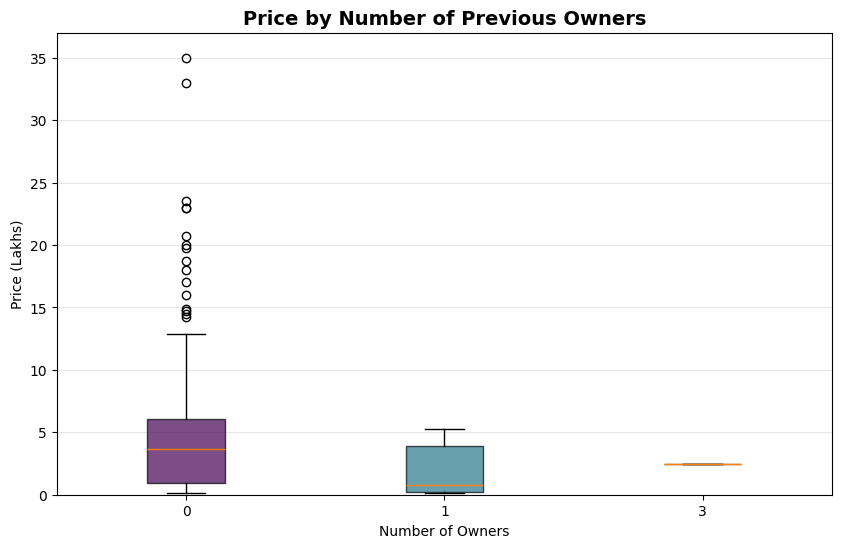

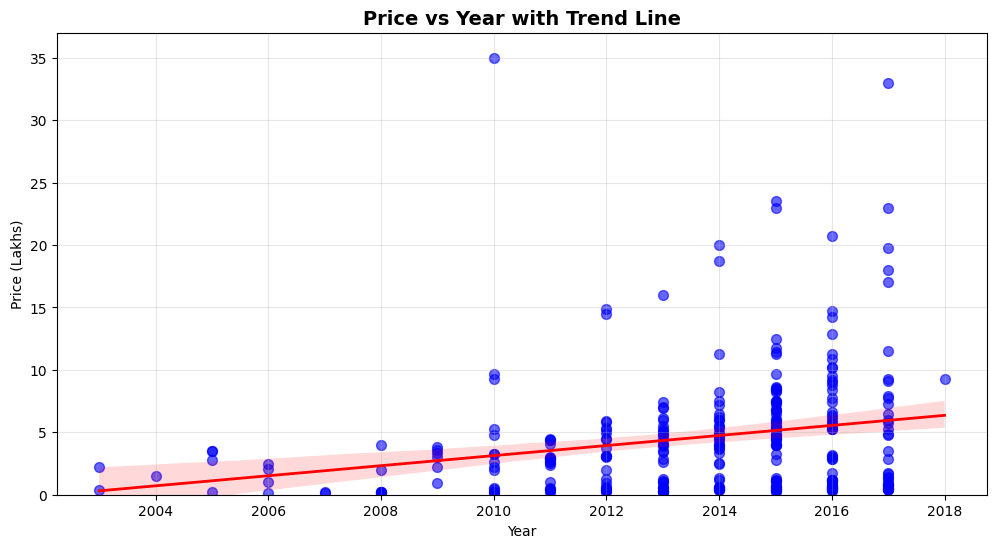

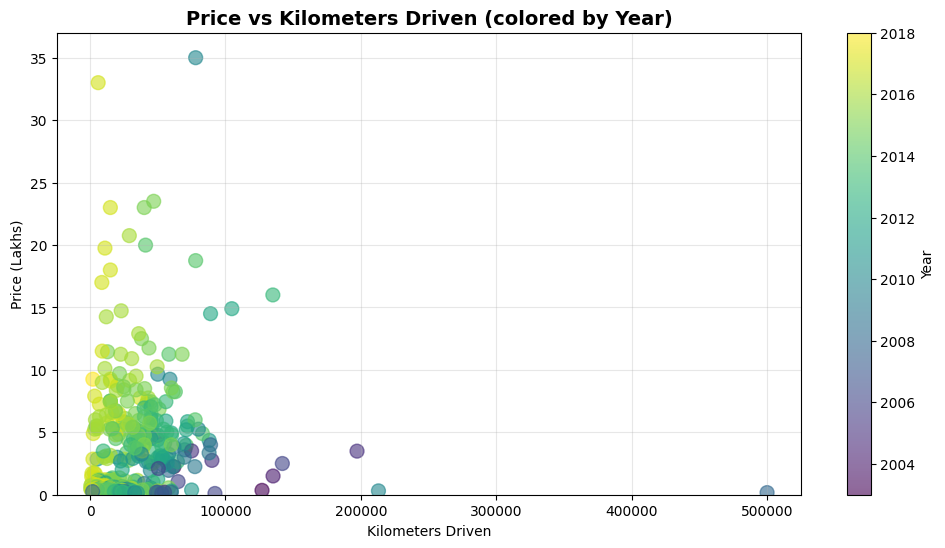

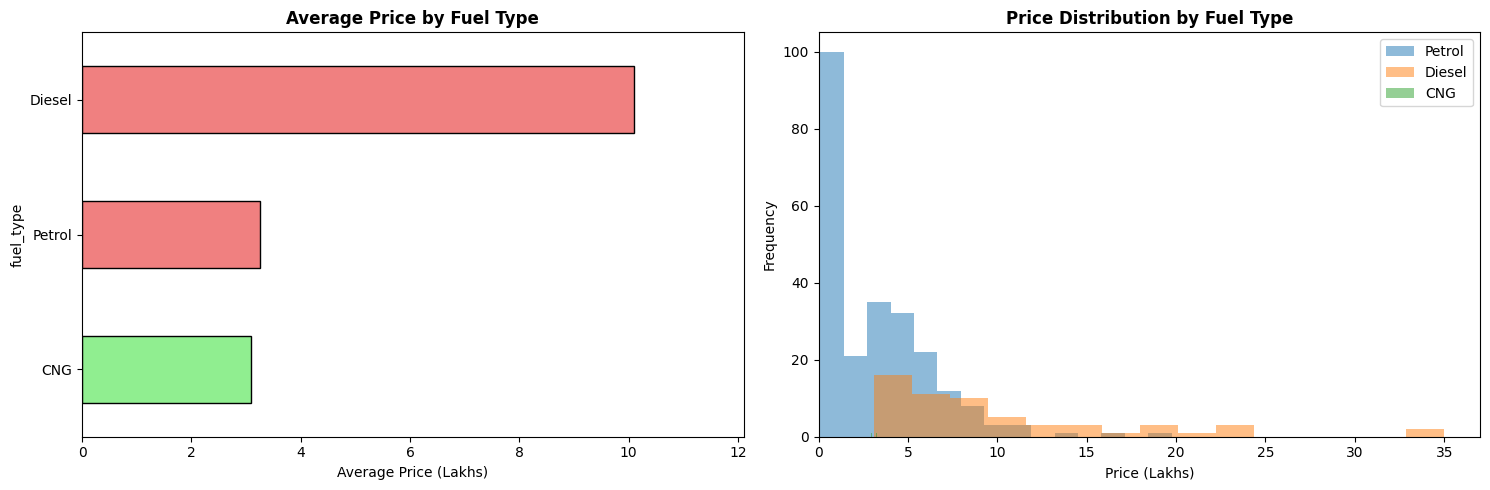


✅ EDA completed successfully!


In [12]:
print("="*60)
print("STEP 3: BASIC EXPLORATORY DATA ANALYSIS")
print("="*60)

# 1. Correlation with price (using 'price')
print("\n📊 Correlation with Price:")
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns
correlations = df_clean[numeric_cols].corr()['price'].abs().sort_values(ascending=False)
print(correlations)

# 2. Price by number of owners - FIXED
plt.figure(figsize=(10, 6))
owner_data = []
owner_labels = sorted(df_clean['Owner'].unique())
for owner in owner_labels:
    owner_data.append(df_clean[df_clean['Owner'] == owner]['price'].values)

bp = plt.boxplot(owner_data, labels=owner_labels, patch_artist=True)
# Color boxes
colors = plt.cm.viridis(np.linspace(0, 0.8, len(owner_labels)))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

plt.title('Price by Number of Previous Owners', fontweight='bold', fontsize=14)
plt.xlabel('Number of Owners')
plt.ylabel('Price (Lakhs)')
plt.ylim(0, df_clean['price'].max() + 2)  # FIXED: Set y-axis limits
plt.grid(True, alpha=0.3, axis='y')
plt.show()

# 3. Price vs Year with regression - FIXED
plt.figure(figsize=(12, 6))
sns.regplot(data=df_clean, x='Year', y='price',
            scatter_kws={'alpha':0.6, 'color': 'blue', 's': 50},
            line_kws={'color': 'red', 'linewidth': 2})
plt.title('Price vs Year with Trend Line', fontweight='bold', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Price (Lakhs)')
plt.ylim(0, df_clean['price'].max() + 2)  # FIXED: Set y-axis limits
plt.grid(True, alpha=0.3)
plt.show()

# 4. Price vs Driven KMs - FIXED
plt.figure(figsize=(12, 6))
# Create a scatter plot with size based on year
scatter = plt.scatter(df_clean['driven_kms'], df_clean['price'],
                     c=df_clean['Year'], cmap='viridis', alpha=0.6, s=100)
plt.colorbar(scatter, label='Year')
plt.title('Price vs Kilometers Driven (colored by Year)', fontweight='bold', fontsize=14)
plt.xlabel('Kilometers Driven')
plt.ylabel('Price (Lakhs)')
plt.ylim(0, df_clean['price'].max() + 2)  # FIXED: Set y-axis limits
plt.grid(True, alpha=0.3)
plt.show()

# 5. Average Price by Fuel Type - FIXED
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
avg_price_fuel = df_clean.groupby('fuel_type')['price'].mean().sort_values()
colors = ['lightgreen' if x < avg_price_fuel.median() else 'lightcoral' for x in avg_price_fuel.values]
avg_price_fuel.plot(kind='barh', color=colors, edgecolor='black')
plt.title('Average Price by Fuel Type', fontweight='bold', fontsize=12)
plt.xlabel('Average Price (Lakhs)')
plt.xlim(0, avg_price_fuel.max() + 2)

plt.subplot(1, 2, 2)
# Price distribution by Fuel Type
for ft in df_clean['fuel_type'].unique():
    data = df_clean[df_clean['fuel_type'] == ft]['price']
    plt.hist(data, alpha=0.5, label=ft, bins=15)
plt.title('Price Distribution by Fuel Type', fontweight='bold', fontsize=12)
plt.xlabel('Price (Lakhs)')
plt.ylabel('Frequency')
plt.legend()
plt.xlim(0, df_clean['price'].max() + 2)

plt.tight_layout()
plt.show()

print("\n✅ EDA completed successfully!")

In [11]:
print("="*70)
print("COMPLETE EXPLORATORY DATA ANALYSIS - CAR PRICE DATASET")
print("="*70)

# ============================================
# 1. BASIC DATASET INFORMATION
# ============================================

print("\n" + "="*50)
print("1. BASIC DATASET INFORMATION")
print("="*50)

print(f"\n📌 Dataset Shape: {df.shape}")
print(f"   - Number of rows: {df.shape[0]}")
print(f"   - Number of columns: {df.shape[1]}")

print("\n📌 Column Names and Data Types:")
print(df.dtypes.to_string())

print("\n📌 First 5 rows:")
print(df.head())

print("\n📌 Last 5 rows:")
print(df.tail())

# ============================================
# 2. DATA QUALITY CHECK
# ============================================

print("\n" + "="*50)
print("2. DATA QUALITY CHECK")
print("="*50)

# Missing values
print("\n📌 Missing Values:")
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing Percentage': missing_pct
})
print(missing_df[missing_df['Missing Count'] > 0] if missing.sum() > 0 else "   No missing values found!")

# Duplicates
duplicates = df.duplicated().sum()
print(f"\n📌 Duplicate Rows: {duplicates}")
if duplicates > 0:
    print(f"   - {duplicates/len(df)*100:.2f}% of data is duplicated")

# Memory usage
memory_usage = df.memory_usage(deep=True).sum() / 1024**2
print(f"\n📌 Memory Usage: {memory_usage:.2f} MB")

# ============================================
# 3. STATISTICAL SUMMARY
# ============================================

print("\n" + "="*50)
print("3. STATISTICAL SUMMARY")
print("="*50)

print("\n📌 Numerical Columns Statistics:")
print(df.describe().round(2))

print("\n📌 Categorical Columns Statistics:")
cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    print(f"\n   {col}:")
    print(f"      - Unique values: {df[col].nunique()}")
    print(f"      - Top value: {df[col].mode()[0]}")
    print(f"      - Top frequency: {df[col].value_counts().iloc[0]} ({df[col].value_counts().iloc[0]/len(df)*100:.1f}%)")

# ============================================
# 4. TARGET VARIABLE ANALYSIS (price)
# ============================================

print("\n" + "="*50)
print("4. TARGET VARIABLE ANALYSIS - PRICE")
print("="*50)

price_stats = {
    'Min Price': df['price'].min(),
    'Max Price': df['price'].max(),
    'Mean Price': df['price'].mean(),
    'Median Price': df['price'].median(),
    'Std Deviation': df['price'].std(),
    'Variance': df['price'].var(),
    'Skewness': df['price'].skew(),
    'Kurtosis': df['price'].kurtosis()
}

print("\n📌 Price Statistics:")
for key, value in price_stats.items():
    print(f"   - {key}: ₹{value:.2f} Lakhs" if 'Price' in key else f"   - {key}: {value:.2f}")

# Price distribution percentiles
percentiles = [0, 10, 25, 50, 75, 90, 95, 99, 100]
price_percentiles = df['price'].quantile([p/100 for p in percentiles])
print("\n📌 Price Percentiles:")
for p in percentiles:
    print(f"   - {p}th percentile: ₹{price_percentiles[p/100]:.2f} Lakhs")

# ============================================
# 5. CATEGORICAL VARIABLES ANALYSIS
# ============================================

print("\n" + "="*50)
print("5. CATEGORICAL VARIABLES ANALYSIS")
print("="*50)

for col in cat_cols:
    print(f"\n📌 {col} Distribution:")
    value_counts = df[col].value_counts()
    for val, count in value_counts.head(5).items():
        print(f"   - {val}: {count} ({count/len(df)*100:.1f}%)")
    if len(value_counts) > 5:
        print(f"   - ... and {len(value_counts)-5} more categories")

# ============================================
# 6. NUMERICAL VARIABLES ANALYSIS
# ============================================

print("\n" + "="*50)
print("6. NUMERICAL VARIABLES ANALYSIS")
print("="*50)

num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if 'price' in num_cols:
    num_cols.remove('price')

print("\n📌 Numerical Features Statistics:")
for col in num_cols:
    print(f"\n   {col}:")
    print(f"      - Min: {df[col].min():.2f}")
    print(f"      - Max: {df[col].max():.2f}")
    print(f"      - Mean: {df[col].mean():.2f}")
    print(f"      - Median: {df[col].median():.2f}")
    print(f"      - Std: {df[col].std():.2f}")

# ============================================
# 7. CORRELATION ANALYSIS
# ============================================

print("\n" + "="*50)
print("7. CORRELATION ANALYSIS")
print("="*50)

# Correlation with price
print("\n📌 Features Correlated with Price:")
corr_with_price = df[num_cols + ['price']].corr()['price'].drop('price').sort_values(ascending=False)
for feat, corr in corr_with_price.items():
    strength = "Very Strong" if abs(corr) > 0.8 else "Strong" if abs(corr) > 0.6 else "Moderate" if abs(corr) > 0.4 else "Weak" if abs(corr) > 0.2 else "Very Weak"
    print(f"   - {feat}: {corr:.3f} ({strength} {'positive' if corr > 0 else 'negative'} correlation)")

# ============================================
# 8. OUTLIER DETECTION
# ============================================

print("\n" + "="*50)
print("8. OUTLIER DETECTION")
print("="*50)

def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return len(outliers), lower_bound, upper_bound

print("\n📌 Outliers in Numerical Columns:")
for col in num_cols + ['price']:
    outlier_count, lower, upper = detect_outliers_iqr(df, col)
    print(f"   - {col}: {outlier_count} outliers ({outlier_count/len(df)*100:.1f}%)")
    if outlier_count > 0:
        print(f"     Range: [{lower:.2f}, {upper:.2f}]")

# ============================================
# 9. YEAR-BASED ANALYSIS
# ============================================

print("\n" + "="*50)
print("9. YEAR-BASED ANALYSIS")
print("="*50)

print(f"\n📌 Year Range: {df['Year'].min()} - {df['Year'].max()}")
print(f"📌 Car Age Range: {2026 - df['Year'].max()} - {2026 - df['Year'].min()} years")

# Cars per year
cars_per_year = df['Year'].value_counts().sort_index()
print("\n📌 Cars Manufactured per Year:")
for year, count in cars_per_year.items():
    print(f"   - {year}: {count} cars")

# Average price by year
avg_price_by_year = df.groupby('Year')['price'].mean().round(2)
print("\n📌 Average Price by Year:")
for year, price in avg_price_by_year.items():
    print(f"   - {year}: ₹{price} Lakhs")

# ============================================
# 10. FUEL TYPE ANALYSIS
# ============================================

print("\n" + "="*50)
print("10. FUEL TYPE ANALYSIS")
print("="*50)

fuel_stats = df.groupby('fuel_type').agg({
    'price': ['count', 'mean', 'min', 'max'],
    'Year': 'mean'
}).round(2)

print("\n📌 Fuel Type Statistics:")
print(fuel_stats)

# ============================================
# 11. TRANSMISSION ANALYSIS
# ============================================

print("\n" + "="*50)
print("11. TRANSMISSION ANALYSIS")
print("="*50)

trans_stats = df.groupby('transmission').agg({
    'price': ['count', 'mean', 'min', 'max'],
    'Year': 'mean'
}).round(2)

print("\n📌 Transmission Statistics:")
print(trans_stats)

# ============================================
# 12. SELLER TYPE ANALYSIS
# ============================================

print("\n" + "="*50)
print("12. SELLER TYPE ANALYSIS")
print("="*50)

seller_stats = df.groupby('selling_type').agg({
    'price': ['count', 'mean', 'min', 'max'],
    'Year': 'mean'
}).round(2)

print("\n📌 Seller Type Statistics:")
print(seller_stats)

# ============================================
# 13. OWNER ANALYSIS
# ============================================

print("\n" + "="*50)
print("13. OWNER ANALYSIS")
print("="*50)

owner_stats = df.groupby('Owner').agg({
    'price': ['count', 'mean', 'min', 'max'],
    'Year': 'mean',
    'driven_kms': 'mean'
}).round(2)

print("\n📌 Owner Statistics:")
print(owner_stats)

# ============================================
# 14. TOP CARS ANALYSIS
# ============================================

print("\n" + "="*50)
print("14. TOP CARS ANALYSIS")
print("="*50)

# Most expensive cars
print("\n📌 Top 10 Most Expensive Cars:")
top_expensive = df.nlargest(10, 'price')[['CarName', 'Year', 'price', 'fuel_type', 'transmission']]
print(top_expensive.to_string(index=False))

# Most affordable cars
print("\n📌 Top 10 Most Affordable Cars:")
top_cheap = df.nsmallest(10, 'price')[['CarName', 'Year', 'price', 'fuel_type', 'transmission']]
print(top_cheap.to_string(index=False))

# Most common cars
print("\n📌 Top 10 Most Common Cars:")
common_cars = df['CarName'].value_counts().head(10)
for car, count in common_cars.items():
    print(f"   - {car}: {count} listings")

# ============================================
# 15. KEY INSIGHTS SUMMARY
# ============================================

print("\n" + "="*50)
print("15. KEY INSIGHTS SUMMARY")
print("="*50)

print("""
📊 DATASET OVERVIEW:
   - Total cars: {} cars
   - Features: {} columns
   - Time period: {} - {}
   - Price range: ₹{:.2f} L - ₹{:.2f} L
   - Average price: ₹{:.2f} L

🔍 DATA QUALITY:
   - Missing values: {}
   - Duplicates: {} rows
   - Memory usage: {:.2f} MB

📈 KEY OBSERVATIONS:
   1. Price Distribution: {}
   2. Most Common Fuel Type: {} ({} cars)
   3. Most Common Transmission: {} ({} cars)
   4. Most Common Seller: {} ({} cars)
   5. Average Car Age: {} years
   6. Most Expensive Car: {} (₹{:.2f} L)
   7. Most Affordable Car: {} (₹{:.2f} L)

🎯 CORRELATION HIGHLIGHTS:
   - Year vs Price: {:.3f} ({})
   - Present Price vs Price: {:.3f} ({})
   - Driven KMs vs Price: {:.3f} ({})
""".format(
    len(df), df.shape[1],
    df['Year'].min(), df['Year'].max(),
    df['price'].min(), df['price'].max(), df['price'].mean(),
    "None" if missing.sum() == 0 else f"{missing.sum()} columns",
    duplicates, memory_usage,
    "Right-skewed (more affordable cars)" if df['price'].skew() > 0 else "Left-skewed (more expensive cars)",
    df['fuel_type'].mode()[0], df['fuel_type'].value_counts().max(),
    df['transmission'].mode()[0], df['transmission'].value_counts().max(),
    df['selling_type'].mode()[0], df['selling_type'].value_counts().max(),
    round(2026 - df['Year'].mean(), 1),
    df.nlargest(1, 'price')['CarName'].values[0], df['price'].max(),
    df.nsmallest(1, 'price')['CarName'].values[0], df['price'].min(),
    corr_with_price.get('Year', 0),
    "positive" if corr_with_price.get('Year', 0) > 0 else "negative",
    corr_with_price.get('present_price', 0),
    "positive" if corr_with_price.get('present_price', 0) > 0 else "negative",
    corr_with_price.get('driven_kms', 0),
    "positive" if corr_with_price.get('driven_kms', 0) > 0 else "negative"
))

print("\n" + "="*70)
print("✅ COMPLETE EDA FINISHED SUCCESSFULLY!")
print("="*70)

COMPLETE EXPLORATORY DATA ANALYSIS - CAR PRICE DATASET

1. BASIC DATASET INFORMATION

📌 Dataset Shape: (301, 9)
   - Number of rows: 301
   - Number of columns: 9

📌 Column Names and Data Types:
CarName           object
Year               int64
price            float64
present_price    float64
driven_kms         int64
fuel_type         object
selling_type      object
transmission      object
Owner              int64

📌 First 5 rows:
   CarName  Year  price  present_price  driven_kms fuel_type selling_type  \
0     ritz  2014   3.35           5.59       27000    Petrol       Dealer   
1      sx4  2013   4.75           9.54       43000    Diesel       Dealer   
2     ciaz  2017   7.25           9.85        6900    Petrol       Dealer   
3  wagon r  2011   2.85           4.15        5200    Petrol       Dealer   
4    swift  2014   4.60           6.87       42450    Diesel       Dealer   

  transmission  Owner  
0       Manual      0  
1       Manual      0  
2       Manual      0  
3   

ADVANCED EXPLORATORY DATA ANALYSIS

STEP 4: ADVANCED EXPLORATORY DATA ANALYSIS

📊 Generating Price Analysis by Categorical Features...


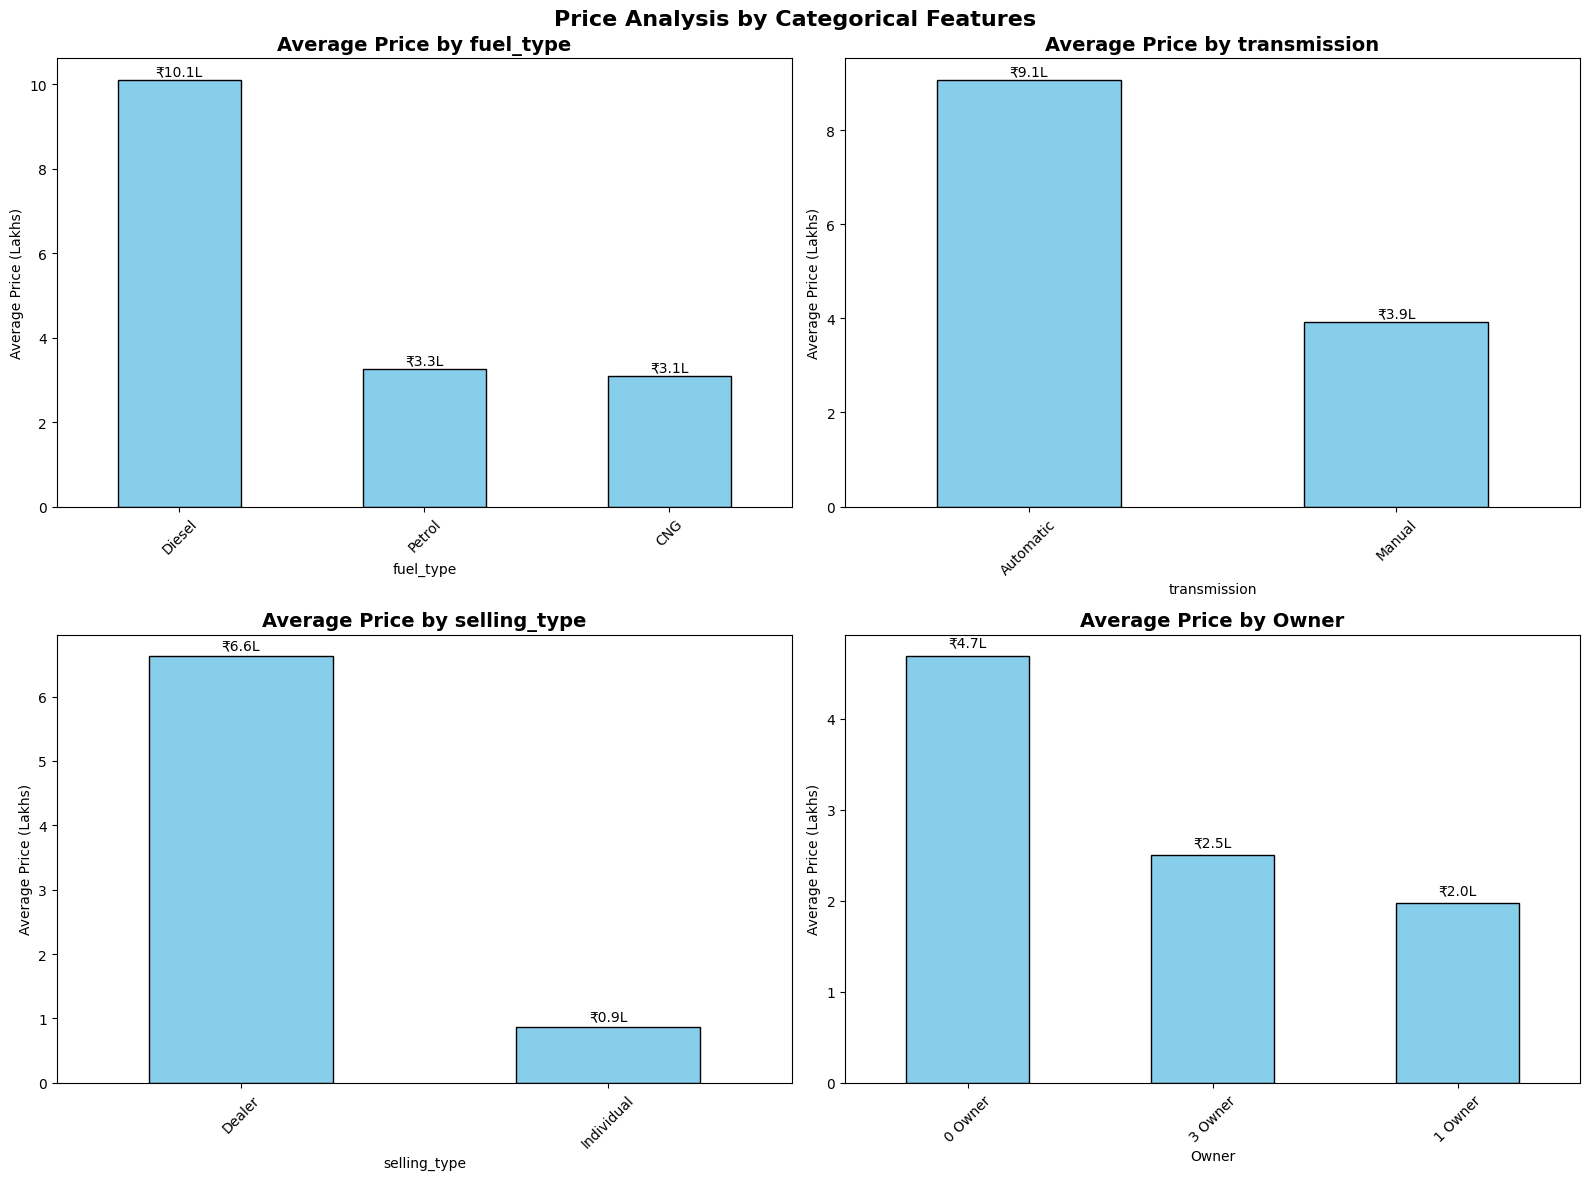


📊 Generating Correlation Heatmap...


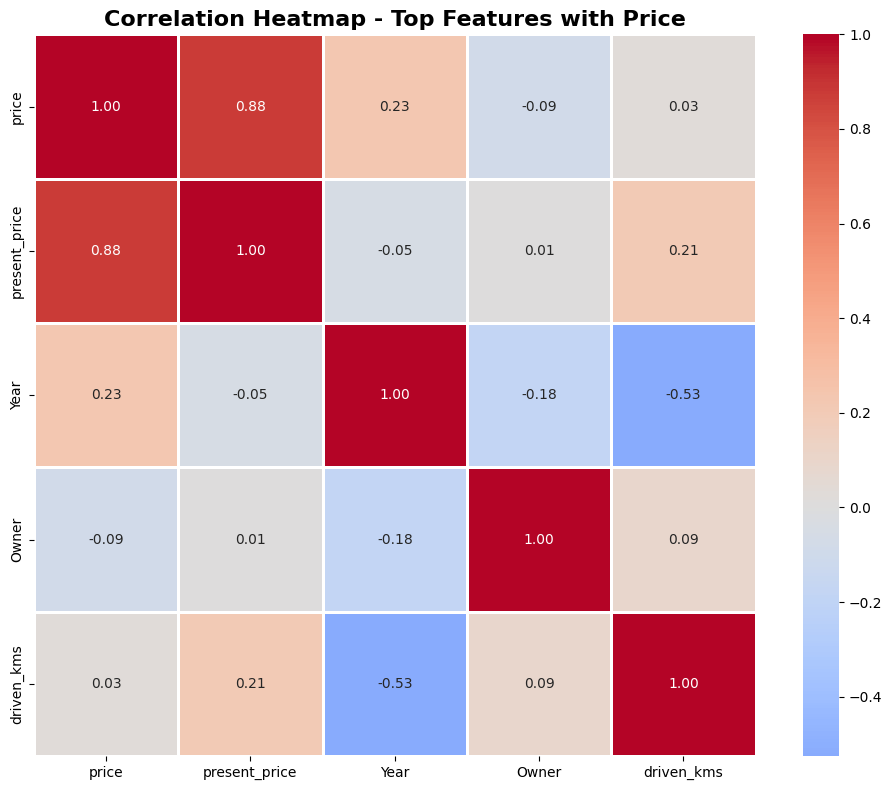


📊 Top Features Correlated with Price:
   - present_price: 0.876
   - Year: 0.234
   - Owner: -0.088
   - driven_kms: 0.029

📊 Generating Pair Plot...


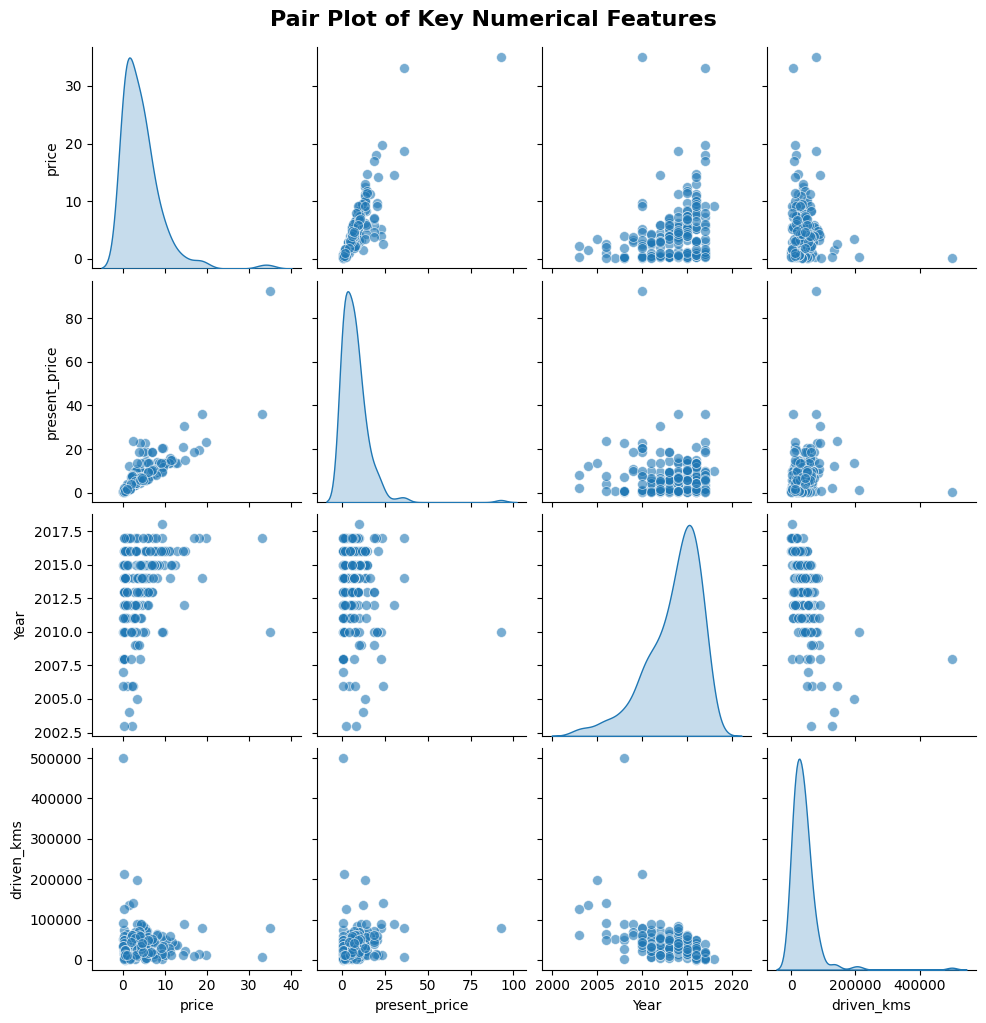


📊 Generating 3D Visualization...



📊 Generating Box Plots...


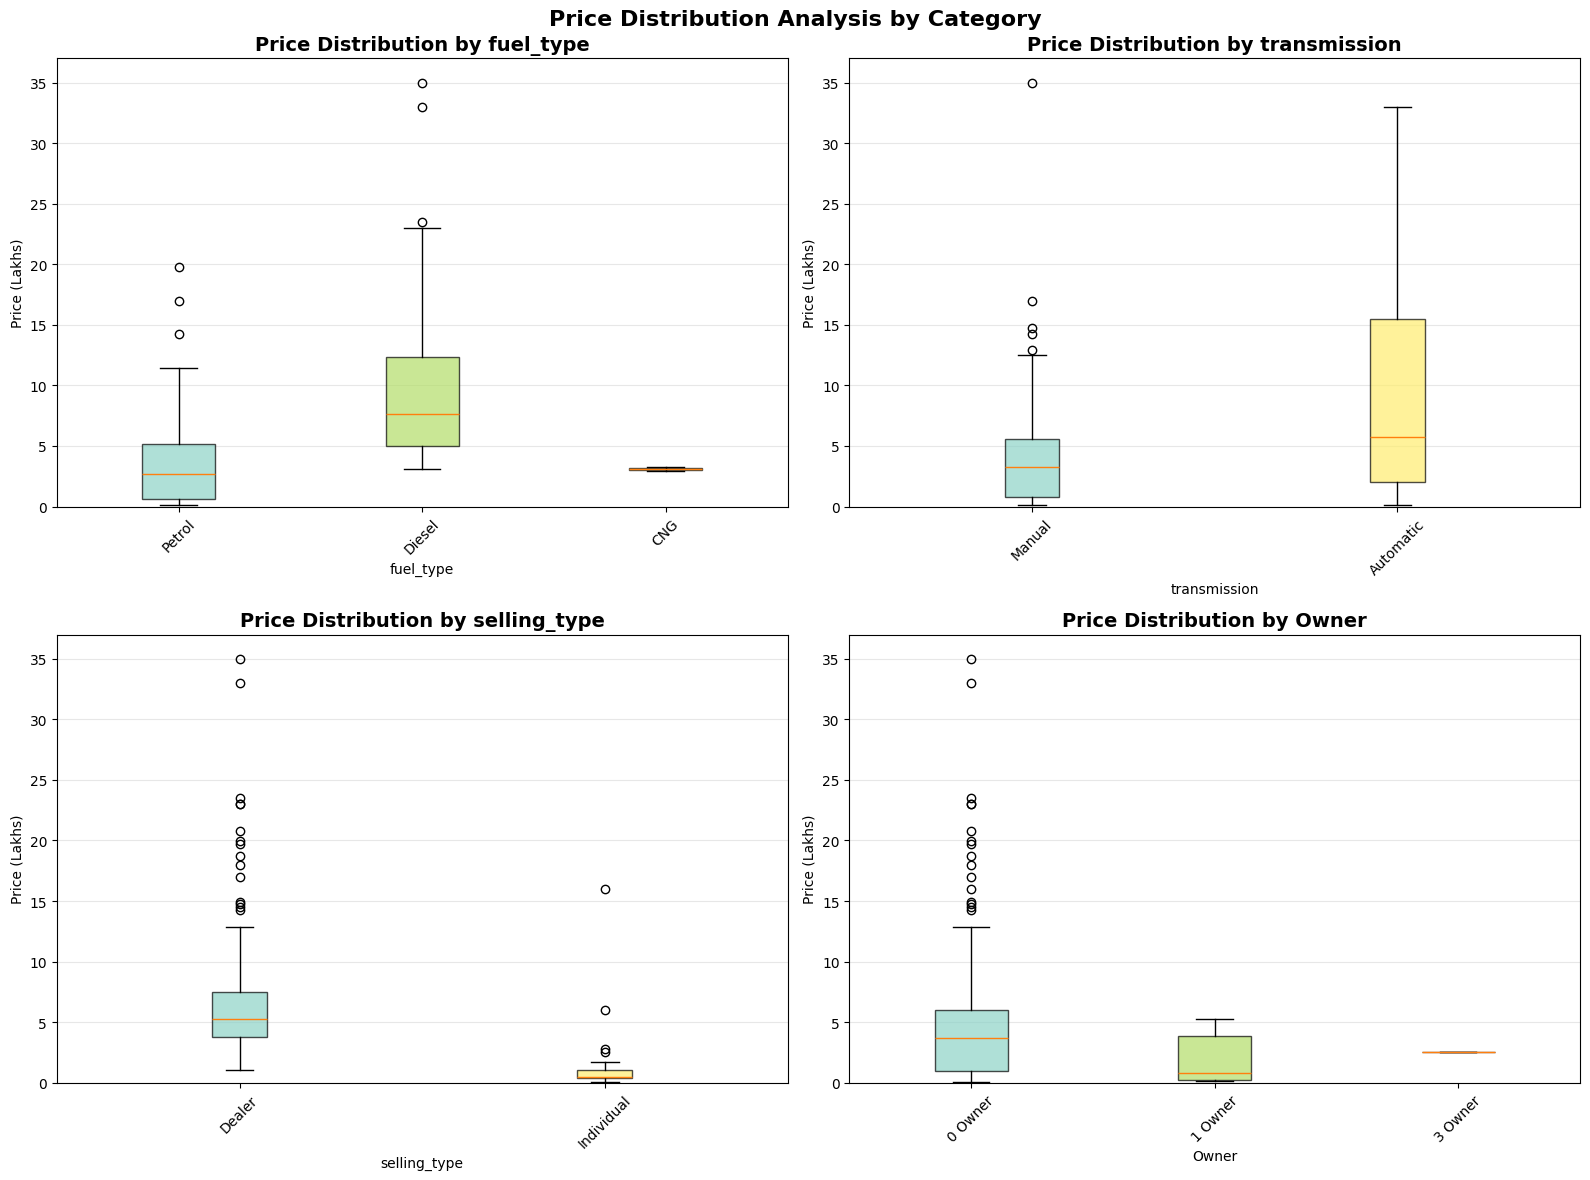


📊 Generating Violin Plots (Alternative View)...


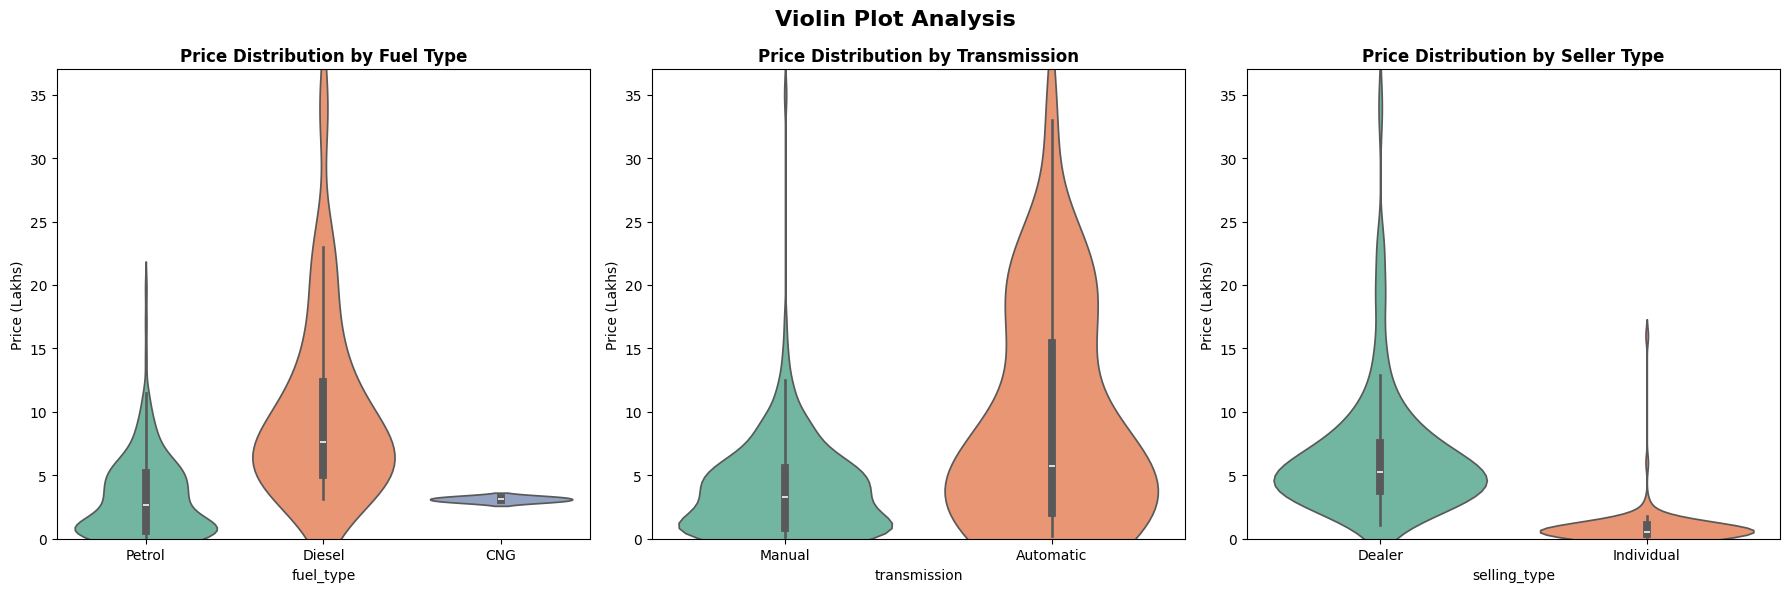


📊 Generating Price vs Year Analysis...


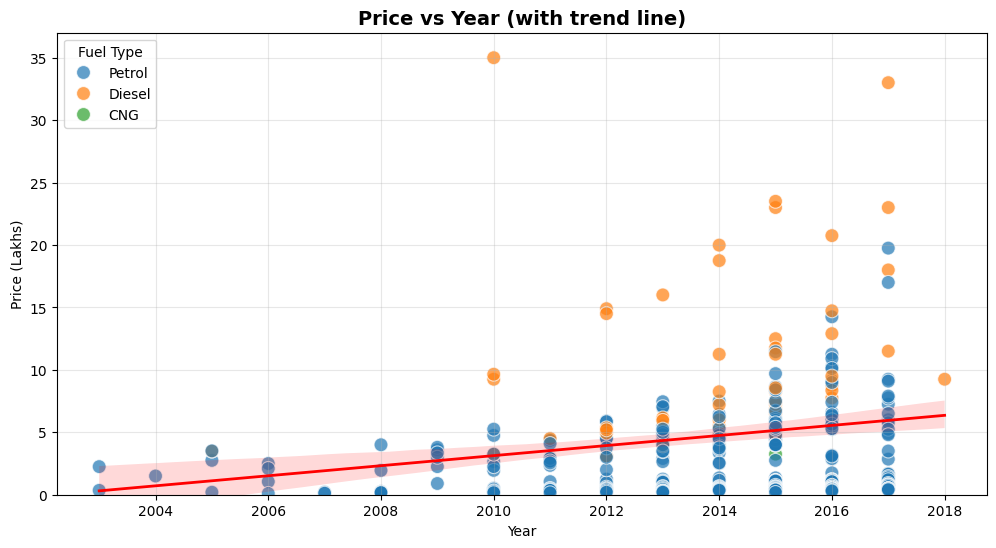


✅ Advanced EDA completed successfully!


In [ ]:
print("="*60)
print("STEP 4: ADVANCED EXPLORATORY DATA ANALYSIS")
print("="*60)

# ============================================
# 1. Price distribution by categorical features (YOUR ACTUAL COLUMNS)
# ============================================

print("\n📊 Generating Price Analysis by Categorical Features...")

# YOUR ACTUAL categorical columns
categorical_features = ['fuel_type', 'transmission', 'selling_type', 'Owner']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.ravel()

for idx, feature in enumerate(categorical_features):
    # Convert Owner to string for better display if it's numeric
    if feature == 'Owner':
        df_clean['Owner_str'] = df_clean['Owner'].astype(str) + ' Owner'
        group_col = 'Owner_str'
    else:
        group_col = feature

    df_grouped = df_clean.groupby(group_col)['price'].mean().sort_values(ascending=False)

    # Plot
    df_grouped.plot(kind='bar', ax=axes[idx], color='skyblue', edgecolor='black')
    axes[idx].set_title(f'Average Price by {feature}', fontweight='bold', fontsize=14)
    axes[idx].set_xlabel(feature)
    axes[idx].set_ylabel('Average Price (Lakhs)')
    axes[idx].tick_params(axis='x', rotation=45)

    # Add value labels on bars
    for i, v in enumerate(df_grouped.values):
        axes[idx].text(i, v + 0.1, f'₹{v:.1f}L', ha='center', fontsize=10)

plt.suptitle('Price Analysis by Categorical Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# ============================================
# 2. Correlation heatmap (all numerical features)
# ============================================

print("\n📊 Generating Correlation Heatmap...")

# Get all numerical columns
numerical_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
if 'price' in numerical_cols:
    numerical_cols.remove('price')

# Calculate correlations with price
correlations = df_clean[numerical_cols + ['price']].corr()['price'].abs().sort_values(ascending=False)
top_features = correlations.head(8).index.tolist()  # Top 8 features including price

plt.figure(figsize=(10, 8))
sns.heatmap(df_clean[top_features].corr(), annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=1, fmt='.2f', annot_kws={'size': 10})
plt.title('Correlation Heatmap - Top Features with Price', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n📊 Top Features Correlated with Price:")
for feat in top_features:
    if feat != 'price':
        corr = df_clean['price'].corr(df_clean[feat])
        print(f"   - {feat}: {corr:.3f}")

# ============================================
# 3. Pair plot of top numerical features
# ============================================

print("\n📊 Generating Pair Plot...")

# Select top numerical features for pair plot
top_num_features = ['price', 'present_price', 'Year', 'driven_kms']
if all(col in df_clean.columns for col in top_num_features):
    # Take a sample for better performance (if dataset is large)
    sample_size = min(200, len(df_clean))
    df_sample = df_clean[top_num_features].sample(sample_size, random_state=42)

    # Create pair plot
    g = sns.pairplot(df_sample, diag_kind='kde', plot_kws={'alpha': 0.6, 's': 50})
    g.fig.suptitle('Pair Plot of Key Numerical Features', fontsize=16, fontweight='bold', y=1.02)
    plt.show()
else:
    print("⚠️ Some columns missing for pair plot")

# ============================================
# 4. 3D Scatter plot (using plotly)
# ============================================

print("\n📊 Generating 3D Visualization...")

try:
    import plotly.express as px

    # Check if required columns exist
    required_cols = ['present_price', 'Year', 'price']
    if all(col in df_clean.columns for col in required_cols):
        fig = px.scatter_3d(df_clean,
                           x='present_price',
                           y='Year',
                           z='price',
                           color='fuel_type',
                           size='driven_kms',
                           hover_data=['CarName', 'transmission', 'selling_type'],
                           title='3D Visualization: Price vs Present Price vs Year',
                           labels={'present_price': 'Present Price (Lakhs)',
                                  'Year': 'Manufacturing Year',
                                  'price': 'Selling Price (Lakhs)'})
        fig.show()
    else:
        print("⚠️ Required columns missing for 3D plot")
except Exception as e:
    print(f"⚠️ 3D plot skipped: {str(e)}")

# ============================================
# 5. Box plots for price by category
# ============================================

print("\n📊 Generating Box Plots...")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.ravel()

box_features = ['fuel_type', 'transmission', 'selling_type', 'Owner']

for idx, feature in enumerate(box_features):
    # Prepare data
    if feature == 'Owner':
        categories = sorted(df_clean['Owner'].unique())
        data_to_plot = [df_clean[df_clean['Owner'] == cat]['price'].values for cat in categories]
        labels = [f'{cat} Owner' for cat in categories]
    else:
        categories = df_clean[feature].unique()
        data_to_plot = [df_clean[df_clean[feature] == cat]['price'].values for cat in categories]
        labels = categories

    # Create boxplot
    bp = axes[idx].boxplot(data_to_plot, labels=labels, patch_artist=True)

    # Color the boxes
    colors = plt.cm.Set3(np.linspace(0, 1, len(categories)))
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    axes[idx].set_title(f'Price Distribution by {feature}', fontweight='bold', fontsize=14)
    axes[idx].set_xlabel(feature)
    axes[idx].set_ylabel('Price (Lakhs)')
    axes[idx].set_ylim(0, df_clean['price'].max() + 2)
    axes[idx].tick_params(axis='x', rotation=45)

    # Add grid
    axes[idx].grid(True, alpha=0.3, axis='y')

plt.suptitle('Price Distribution Analysis by Category', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# ============================================
# 6. Additional Analysis - Price by Fuel Type with Violin Plots
# ============================================

print("\n📊 Generating Violin Plots (Alternative View)...")

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Violin plot for fuel type
sns.violinplot(data=df_clean, x='fuel_type', y='price', ax=axes[0], palette='Set2')
axes[0].set_title('Price Distribution by Fuel Type', fontweight='bold')
axes[0].set_ylabel('Price (Lakhs)')
axes[0].set_ylim(0, df_clean['price'].max() + 2)

# Violin plot for transmission
sns.violinplot(data=df_clean, x='transmission', y='price', ax=axes[1], palette='Set2')
axes[1].set_title('Price Distribution by Transmission', fontweight='bold')
axes[1].set_ylabel('Price (Lakhs)')
axes[1].set_ylim(0, df_clean['price'].max() + 2)

# Violin plot for seller type
sns.violinplot(data=df_clean, x='selling_type', y='price', ax=axes[2], palette='Set2')
axes[2].set_title('Price Distribution by Seller Type', fontweight='bold')
axes[2].set_ylabel('Price (Lakhs)')
axes[2].set_ylim(0, df_clean['price'].max() + 2)

plt.suptitle('Violin Plot Analysis', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# ============================================
# 7. Price vs Year with regression by Fuel Type
# ============================================

print("\n📊 Generating Price vs Year Analysis...")

plt.figure(figsize=(12, 6))
sns.scatterplot(data=df_clean, x='Year', y='price', hue='fuel_type', alpha=0.7, s=100)
sns.regplot(data=df_clean, x='Year', y='price', scatter=False, color='red', line_kws={'linewidth': 2})
plt.title('Price vs Year (with trend line)', fontweight='bold', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Price (Lakhs)')
plt.ylim(0, df_clean['price'].max() + 2)
plt.legend(title='Fuel Type')
plt.grid(True, alpha=0.3)
plt.show()

print("\n✅ Advanced EDA completed successfully!")

DATA VISUALIZATION


📊 Price Analysis by Categorical Features...


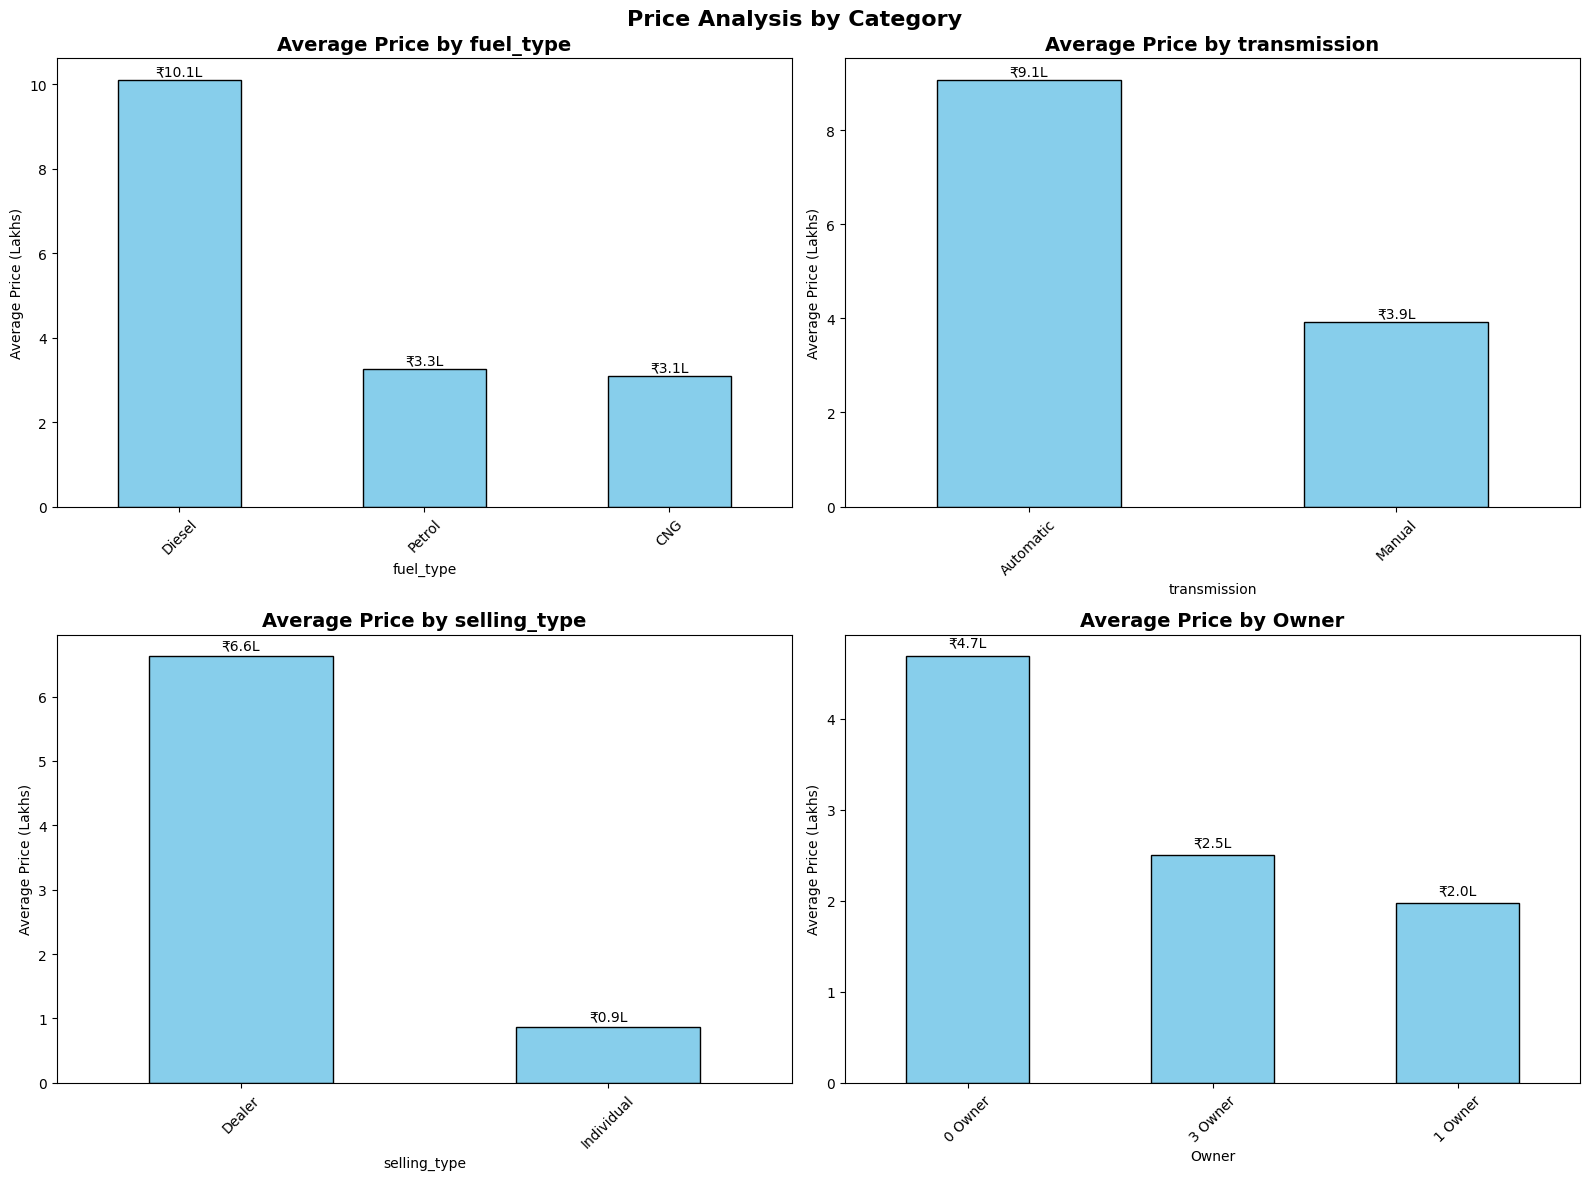


📊 Correlation Heatmap...


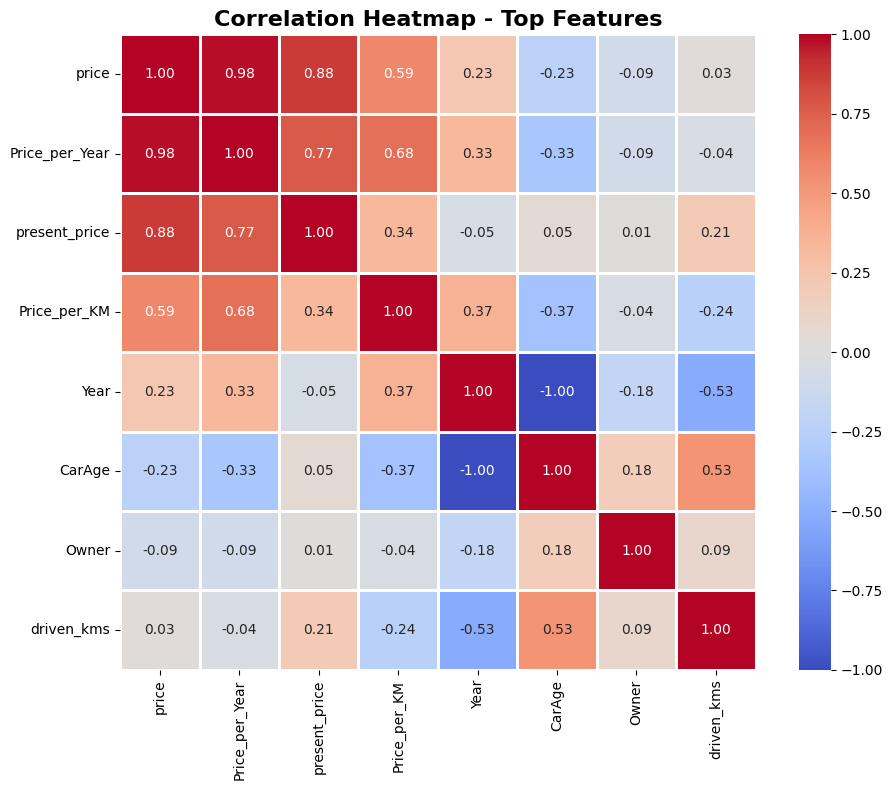


📊 Top Features Correlated with Price:
   - Price_per_Year: 0.977
   - present_price: 0.876
   - Price_per_KM: 0.585
   - Year: 0.234
   - CarAge: -0.234
   - Owner: -0.088
   - driven_kms: 0.029

📊 Price Distribution by Fuel Type...


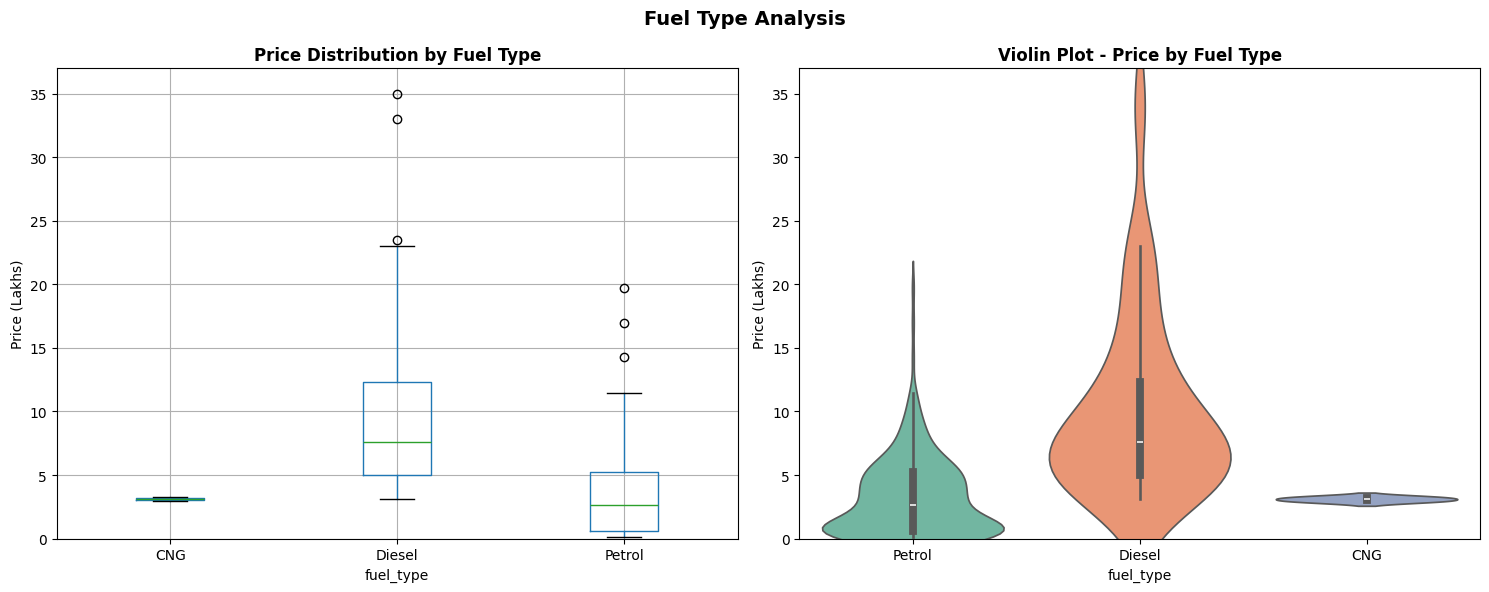


📊 Price vs Year Analysis...


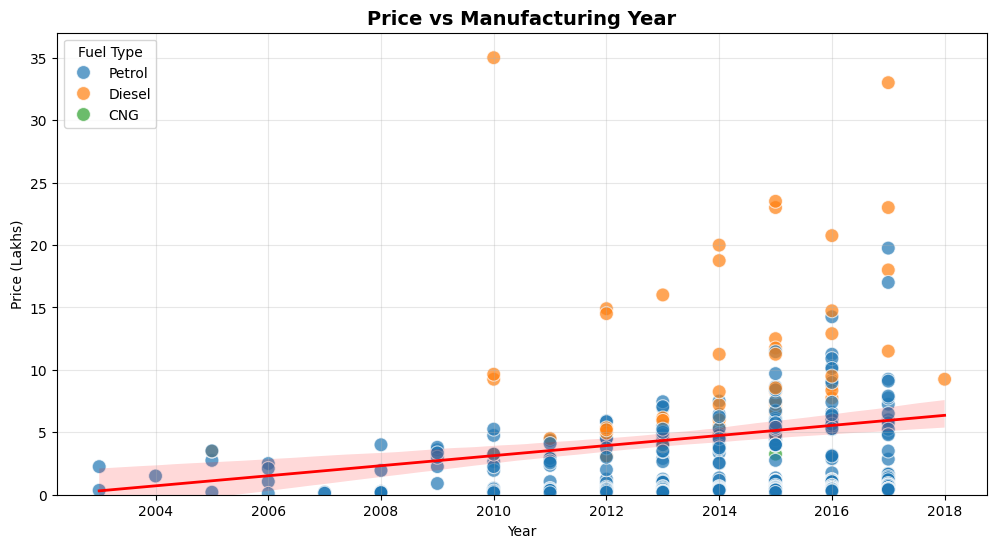


✅ EDA completed successfully!


In [35]:
# 1. Price distribution by categorical features
print("\n📊 Price Analysis by Categorical Features...")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.ravel()

categorical_features = ['fuel_type', 'transmission', 'selling_type', 'Owner']

for idx, feature in enumerate(categorical_features):
    if feature == 'Owner':
        df_clean['Owner_str'] = df_clean['Owner'].astype(str) + ' Owner'
        group_col = 'Owner_str'
    else:
        group_col = feature

    df_grouped = df_clean.groupby(group_col)['price'].mean().sort_values(ascending=False)

    df_grouped.plot(kind='bar', ax=axes[idx], color='skyblue', edgecolor='black')
    axes[idx].set_title(f'Average Price by {feature}', fontweight='bold', fontsize=14)
    axes[idx].set_xlabel(feature)
    axes[idx].set_ylabel('Average Price (Lakhs)')
    axes[idx].tick_params(axis='x', rotation=45)

    # Add value labels
    for i, v in enumerate(df_grouped.values):
        axes[idx].text(i, v + 0.1, f'₹{v:.1f}L', ha='center', fontsize=10)

plt.suptitle('Price Analysis by Category', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# 2. Correlation heatmap
print("\n📊 Correlation Heatmap...")

numerical_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
if 'price' in numerical_cols:
    numerical_cols.remove('price')

# Get top correlated features
correlations = df_clean[numerical_cols + ['price']].corr()['price'].abs().sort_values(ascending=False)
top_features = correlations.head(8).index.tolist()

plt.figure(figsize=(10, 8))
sns.heatmap(df_clean[top_features].corr(), annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=1, fmt='.2f', annot_kws={'size': 10})
plt.title('Correlation Heatmap - Top Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n📊 Top Features Correlated with Price:")
for feat in top_features:
    if feat != 'price':
        corr = df_clean['price'].corr(df_clean[feat])
        print(f"   - {feat}: {corr:.3f}")

# 3. Price distribution by fuel type
print("\n📊 Price Distribution by Fuel Type...")

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Box plot
df_clean.boxplot(column='price', by='fuel_type', ax=axes[0])
axes[0].set_title('Price Distribution by Fuel Type', fontweight='bold')
axes[0].set_ylabel('Price (Lakhs)')
axes[0].set_ylim(0, df_clean['price'].max() + 2)

# Violin plot
sns.violinplot(data=df_clean, x='fuel_type', y='price', ax=axes[1], palette='Set2')
axes[1].set_title('Violin Plot - Price by Fuel Type', fontweight='bold')
axes[1].set_ylabel('Price (Lakhs)')
axes[1].set_ylim(0, df_clean['price'].max() + 2)

plt.suptitle('Fuel Type Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 4. Price vs Year scatter
print("\n📊 Price vs Year Analysis...")

plt.figure(figsize=(12, 6))
sns.scatterplot(data=df_clean, x='Year', y='price', hue='fuel_type', alpha=0.7, s=100)
sns.regplot(data=df_clean, x='Year', y='price', scatter=False, color='red', line_kws={'linewidth': 2})
plt.title('Price vs Manufacturing Year', fontweight='bold', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Price (Lakhs)')
plt.ylim(0, df_clean['price'].max() + 2)
plt.legend(title='Fuel Type')
plt.grid(True, alpha=0.3)
plt.show()

print("\n✅ EDA completed successfully!")

DATA PREPARATION FOR MODELING

In [13]:
print("="*60)
print("STEP 5: DATA PREPARATION FOR MODELING")
print("="*60)

# Define features and target
target = 'price'

# Identify column types
categorical_cols = df_clean.select_dtypes(include=['object']).columns.tolist()
numerical_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()

# Remove target from features
if target in numerical_cols:
    numerical_cols.remove(target)

print(f"\n📊 Feature Types:")
print(f"   - Numerical features: {len(numerical_cols)}")
print(f"   - Categorical features: {len(categorical_cols)}")

print("\n📋 Numerical Features:")
print(f"   {numerical_cols}")

print("\n📋 Categorical Features:")
print(f"   {categorical_cols}")

# Create feature matrix and target
X = df_clean[numerical_cols + categorical_cols]
y = df_clean[target]

print(f"\n✅ Feature matrix shape: {X.shape}")
print(f"✅ Target shape: {y.shape}")

# CRITICAL FIX: Split data FIRST before any preprocessing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\n📊 Data Split:")
print(f"   - Training set: {X_train.shape[0]} samples ({len(X_train)/len(X)*100:.1f}%)")
print(f"   - Testing set: {X_test.shape[0]} samples ({len(X_test)/len(X)*100:.1f}%)")

# Store for later use
X_train_original = X_train.copy()
X_test_original = X_test.copy()

STEP 5: DATA PREPARATION FOR MODELING

📊 Feature Types:
   - Numerical features: 7
   - Categorical features: 8

📋 Numerical Features:
   ['Year', 'present_price', 'driven_kms', 'Owner', 'CarAge', 'Price_per_Year', 'Price_per_KM']

📋 Categorical Features:
   ['CarName', 'fuel_type', 'selling_type', 'transmission', 'CarBrand', 'Brand_Type', 'Trans_Owner', 'Owner_str']

✅ Feature matrix shape: (299, 15)
✅ Target shape: (299,)

📊 Data Split:
   - Training set: 239 samples (79.9%)
   - Testing set: 60 samples (20.1%)


CREATE PREPROCESSING PIPELINE

In [14]:
print("="*60)
print("STEP 6: CREATING PREPROCESSING PIPELINE")
print("="*60)

# Numerical pipeline
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical pipeline
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Combine preprocessors
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

# CRITICAL: Fit on TRAINING data only!
print("🔄 Fitting preprocessor on TRAINING data only...")
preprocessor.fit(X_train)

print("✅ Preprocessing pipeline created and fitted successfully!")

# Transform both sets
print("🔄 Transforming training and test data...")
X_train_processed = preprocessor.transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(f"\n📊 Processed Data Shapes:")
print(f"   - X_train_processed: {X_train_processed.shape}")
print(f"   - X_test_processed: {X_test_processed.shape}")

# Get feature names after preprocessing
cat_feature_names = []
for i, col in enumerate(categorical_cols):
    cats = preprocessor.named_transformers_['cat'].named_steps['onehot'].categories_[i]
    cat_feature_names.extend([f"{col}_{cat}" for cat in cats])

feature_names = numerical_cols + cat_feature_names
print(f"\n✅ Total features after encoding: {len(feature_names)}")

STEP 6: CREATING PREPROCESSING PIPELINE
🔄 Fitting preprocessor on TRAINING data only...
✅ Preprocessing pipeline created and fitted successfully!
🔄 Transforming training and test data...

📊 Processed Data Shapes:
   - X_train_processed: (239, 195)
   - X_test_processed: (60, 195)

✅ Total features after encoding: 195


FEATURE SELECTION

STEP 7: FEATURE SELECTION


<Figure size 1200x800 with 0 Axes>

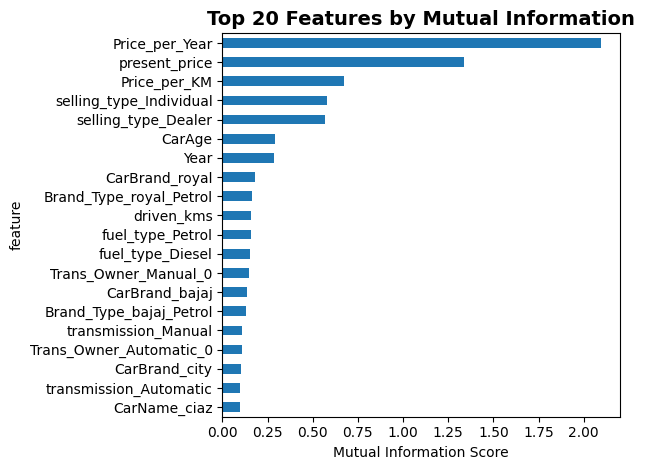


📊 Top 10 Most Important Features:
                     feature  importance
5             Price_per_Year    2.095925
1              present_price    1.335628
6               Price_per_KM    0.675109
96   selling_type_Individual    0.579854
95       selling_type_Dealer    0.567033
4                     CarAge    0.288501
0                       Year    0.286688
128           CarBrand_royal    0.179879
176  Brand_Type_royal_Petrol    0.165554
2                 driven_kms    0.159648


In [15]:
print("="*60)
print("STEP 7: FEATURE SELECTION")
print("="*60)

# Mutual information for feature selection
mi_scores = mutual_info_regression(X_train_processed, y_train, random_state=42)

# Create dataframe for visualization
mi_df = pd.DataFrame({
    'feature': feature_names[:len(mi_scores)],
    'importance': mi_scores
}).sort_values('importance', ascending=False)

plt.figure(figsize=(12, 8))
mi_df.head(20).plot(x='feature', y='importance', kind='barh', legend=False)
plt.title('Top 20 Features by Mutual Information', fontweight='bold', fontsize=14)
plt.xlabel('Mutual Information Score')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\n📊 Top 10 Most Important Features:")
print(mi_df.head(10))

# Keep all features for now (you can select top k if needed)
# X_train_selected = X_train_processed
# X_test_selected = X_test_processed

MODEL DEFINITIONS

In [16]:
print("="*60)
print("STEP 8: MODEL DEFINITIONS")
print("="*60)

# Define models to train
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(random_state=42),
    'Lasso Regression': Lasso(random_state=42),
    'ElasticNet': ElasticNet(random_state=42),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42),
    'XGBoost': XGBRegressor(random_state=42, n_jobs=-1, eval_metric='rmse'),
    'LightGBM': LGBMRegressor(random_state=42, verbose=-1, n_jobs=-1),
    'CatBoost': CatBoostRegressor(random_state=42, verbose=0),
    'Extra Trees': ExtraTreesRegressor(random_state=42, n_jobs=-1),
    'AdaBoost': AdaBoostRegressor(random_state=42)
}

print(f"✅ Defined {len(models)} models for training")
print("\n📋 Models:")
for name in models.keys():
    print(f"   - {name}")

STEP 8: MODEL DEFINITIONS
✅ Defined 12 models for training

📋 Models:
   - Linear Regression
   - Ridge Regression
   - Lasso Regression
   - ElasticNet
   - Decision Tree
   - Random Forest
   - Gradient Boosting
   - XGBoost
   - LightGBM
   - CatBoost
   - Extra Trees
   - AdaBoost


CREATE FULL PIPELINES

In [17]:
print("="*60)
print("STEP 9: CREATING MODEL PIPELINES")
print("="*60)

pipelines = {}

for name, model in models.items():
    pipelines[name] = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('regressor', model)
    ])
    print(f"✅ Pipeline created: {name}")

STEP 9: CREATING MODEL PIPELINES
✅ Pipeline created: Linear Regression
✅ Pipeline created: Ridge Regression
✅ Pipeline created: Lasso Regression
✅ Pipeline created: ElasticNet
✅ Pipeline created: Decision Tree
✅ Pipeline created: Random Forest
✅ Pipeline created: Gradient Boosting
✅ Pipeline created: XGBoost
✅ Pipeline created: LightGBM
✅ Pipeline created: CatBoost
✅ Pipeline created: Extra Trees
✅ Pipeline created: AdaBoost


MODEL TRAINING WITH CROSS-VALIDATION

In [18]:
print("="*60)
print("STEP 9: MODEL TRAINING & CROSS-VALIDATION")
print("="*60)

results = {}
trained_models = {}

# Cross-validation settings
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    print(f"\n{'='*50}")
    print(f"🔄 Training: {name}")
    print(f"{'='*50}")

    start_time = time.time()

    try:
        # Train model on processed training data
        model.fit(X_train_processed, y_train)

        # Cross-validation on training data
        cv_scores = cross_val_score(model, X_train_processed, y_train,
                                   cv=kfold, scoring='r2')
        cv_rmse = np.sqrt(-cross_val_score(model, X_train_processed, y_train,
                                          cv=kfold, scoring='neg_mean_squared_error'))
        cv_mae = -cross_val_score(model, X_train_processed, y_train,
                                  cv=kfold, scoring='neg_mean_absolute_error')

        training_time = time.time() - start_time

        # Store results
        results[name] = {
            'CV_R2_Mean': cv_scores.mean(),
            'CV_R2_Std': cv_scores.std(),
            'CV_RMSE_Mean': cv_rmse.mean(),
            'CV_RMSE_Std': cv_rmse.std(),
            'CV_MAE_Mean': cv_mae.mean(),
            'CV_MAE_Std': cv_mae.std(),
            'Training_Time': training_time
        }

        trained_models[name] = model

        print(f"\n📊 Cross-Validation Results:")
        print(f"   R² Score: {cv_scores.mean():.4f} (±{cv_scores.std():.4f})")
        print(f"   RMSE: ₹{cv_rmse.mean():.2f}L (±{cv_rmse.std():.2f}L)")
        print(f"   MAE: ₹{cv_mae.mean():.2f}L (±{cv_mae.std():.2f}L)")
        print(f"   Training Time: {training_time:.2f} seconds")

    except Exception as e:
        print(f"❌ Error training {name}: {str(e)}")

# Create results dataframe
results_df = pd.DataFrame(results).T.sort_values('CV_R2_Mean', ascending=False)
print("\n" + "="*60)
print("📊 MODEL COMPARISON SUMMARY")
print("="*60)
print(results_df.round(4))

STEP 9: MODEL TRAINING & CROSS-VALIDATION

🔄 Training: Linear Regression

📊 Cross-Validation Results:
   R² Score: 0.9905 (±0.0025)
   RMSE: ₹0.48L (±0.16L)
   MAE: ₹0.27L (±0.03L)
   Training Time: 0.17 seconds

🔄 Training: Ridge Regression

📊 Cross-Validation Results:
   R² Score: 0.9934 (±0.0012)
   RMSE: ₹0.39L (±0.09L)
   MAE: ₹0.23L (±0.02L)
   Training Time: 0.18 seconds

🔄 Training: Lasso Regression

📊 Cross-Validation Results:
   R² Score: 0.9344 (±0.0285)
   RMSE: ₹1.26L (±0.53L)
   MAE: ₹0.81L (±0.18L)
   Training Time: 0.09 seconds

🔄 Training: ElasticNet

📊 Cross-Validation Results:
   R² Score: 0.8904 (±0.0071)
   RMSE: ₹1.60L (±0.31L)
   MAE: ₹1.15L (±0.20L)
   Training Time: 0.06 seconds

🔄 Training: Decision Tree

📊 Cross-Validation Results:
   R² Score: 0.9275 (±0.0456)
   RMSE: ₹1.26L (±0.43L)
   MAE: ₹0.55L (±0.08L)
   Training Time: 0.08 seconds

🔄 Training: Random Forest

📊 Cross-Validation Results:
   R² Score: 0.9668 (±0.0308)
   RMSE: ₹0.87L (±0.60L)
   MAE: ₹0

HYPERPARAMETER TUNING (OPTUNA)

In [19]:
print("="*60)
print("STEP 10: HYPERPARAMETER TUNING WITH OPTUNA")
print("="*60)

# Select top 3 models for tuning
top_models = results_df.head(3).index.tolist()
print(f"\n🎯 Tuning top models: {top_models}")

tuned_models = {}

def objective_rf(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 300),
        'max_depth': trial.suggest_int('max_depth', 5, 20),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 5),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None])
    }

    model = RandomForestRegressor(**params, random_state=42, n_jobs=-1)
    scores = cross_val_score(model, X_train_processed, y_train, cv=5, scoring='r2')
    return scores.mean()

def objective_et(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 300),
        'max_depth': trial.suggest_int('max_depth', 5, 20),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 5),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None])
    }

    model = ExtraTreesRegressor(**params, random_state=42, n_jobs=-1)
    scores = cross_val_score(model, X_train_processed, y_train, cv=5, scoring='r2')
    return scores.mean()

def objective_gb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 300),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 5)
    }

    model = GradientBoostingRegressor(**params, random_state=42)
    scores = cross_val_score(model, X_train_processed, y_train, cv=5, scoring='r2')
    return scores.mean()

# Tune Random Forest
if 'Random Forest' in top_models:
    print("\n🔄 Tuning Random Forest...")
    study_rf = optuna.create_study(direction='maximize')
    study_rf.optimize(objective_rf, n_trials=20, show_progress_bar=True)

    best_rf = RandomForestRegressor(**study_rf.best_params, random_state=42, n_jobs=-1)
    best_rf.fit(X_train_processed, y_train)
    tuned_models['Random Forest (Tuned)'] = best_rf

    print(f"\n✅ Best parameters for Random Forest:")
    for param, value in study_rf.best_params.items():
        print(f"   - {param}: {value}")
    print(f"   Best CV Score: {study_rf.best_value:.4f}")

# Tune Extra Trees
if 'Extra Trees' in top_models:
    print("\n🔄 Tuning Extra Trees...")
    study_et = optuna.create_study(direction='maximize')
    study_et.optimize(objective_et, n_trials=20, show_progress_bar=True)

    best_et = ExtraTreesRegressor(**study_et.best_params, random_state=42, n_jobs=-1)
    best_et.fit(X_train_processed, y_train)
    tuned_models['Extra Trees (Tuned)'] = best_et

    print(f"\n✅ Best parameters for Extra Trees:")
    for param, value in study_et.best_params.items():
        print(f"   - {param}: {value}")
    print(f"   Best CV Score: {study_et.best_value:.4f}")

# Tune Gradient Boosting
if 'Gradient Boosting' in top_models:
    print("\n🔄 Tuning Gradient Boosting...")
    study_gb = optuna.create_study(direction='maximize')
    study_gb.optimize(objective_gb, n_trials=20, show_progress_bar=True)

    best_gb = GradientBoostingRegressor(**study_gb.best_params, random_state=42)
    best_gb.fit(X_train_processed, y_train)
    tuned_models['Gradient Boosting (Tuned)'] = best_gb

    print(f"\n✅ Best parameters for Gradient Boosting:")
    for param, value in study_gb.best_params.items():
        print(f"   - {param}: {value}")
    print(f"   Best CV Score: {study_gb.best_value:.4f}")

# Add original top models to tuned_models for comparison
for name in top_models:
    if name in trained_models:
        tuned_models[name] = trained_models[name]

[I 2026-03-10 13:26:32,916] A new study created in memory with name: no-name-42931c15-126f-400f-8b5a-866e3e417b2a


STEP 10: HYPERPARAMETER TUNING WITH OPTUNA

🎯 Tuning top models: ['Ridge Regression', 'Linear Regression', 'Gradient Boosting']

🔄 Tuning Gradient Boosting...


  0%|          | 0/20 [00:00<?, ?it/s]

[I 2026-03-10 13:26:35,666] Trial 0 finished with value: 0.965505850616934 and parameters: {'n_estimators': 258, 'max_depth': 6, 'learning_rate': 0.025619211315080458, 'subsample': 0.9524043869878803, 'min_samples_split': 4, 'min_samples_leaf': 5}. Best is trial 0 with value: 0.965505850616934.
[I 2026-03-10 13:26:39,083] Trial 1 finished with value: 0.965717940523046 and parameters: {'n_estimators': 262, 'max_depth': 9, 'learning_rate': 0.1666050697232609, 'subsample': 0.893140616688571, 'min_samples_split': 7, 'min_samples_leaf': 4}. Best is trial 1 with value: 0.965717940523046.
[I 2026-03-10 13:26:42,888] Trial 2 finished with value: 0.9467217417837247 and parameters: {'n_estimators': 245, 'max_depth': 9, 'learning_rate': 0.1978963126426019, 'subsample': 0.826203863686277, 'min_samples_split': 7, 'min_samples_leaf': 1}. Best is trial 1 with value: 0.965717940523046.
[I 2026-03-10 13:26:43,755] Trial 3 finished with value: 0.9647179103521459 and parameters: {'n_estimators': 102, 'ma

CREATE ENSEMBLE MODELS

In [20]:
print("="*60)
print("STEP 11: CREATING ENSEMBLE MODELS")
print("="*60)

# Collect top models for ensemble
ensemble_models = []
for name in tuned_models.keys():
    if any(x in name for x in ['Random Forest', 'Extra Trees', 'Gradient Boosting', 'XGBoost']):
        ensemble_models.append((name, tuned_models[name]))

# Voting Regressor
if len(ensemble_models) >= 2:
    voting_reg = VotingRegressor(estimators=ensemble_models[:3])  # Use top 3
    voting_reg.fit(X_train_processed, y_train)
    tuned_models['Voting Ensemble'] = voting_reg
    print("✅ Voting Ensemble created successfully")

# Stacking Regressor
if len(ensemble_models) >= 3:
    base_models = ensemble_models[:3]
    meta_model = Ridge(alpha=1.0)
    stacking_reg = StackingRegressor(estimators=base_models, final_estimator=meta_model, cv=5)
    stacking_reg.fit(X_train_processed, y_train)
    tuned_models['Stacking Ensemble'] = stacking_reg
    print("✅ Stacking Ensemble created successfully")

STEP 11: CREATING ENSEMBLE MODELS
✅ Voting Ensemble created successfully


MODEL EVALUATION ON TEST SET

STEP 12: MODEL EVALUATION ON TEST SET

📊 Evaluating: Gradient Boosting (Tuned)

📈 Performance Metrics:
   R² Score: 0.9552
   RMSE: ₹1.07L
   MAE: ₹0.40L
   MAPE: 12.10%


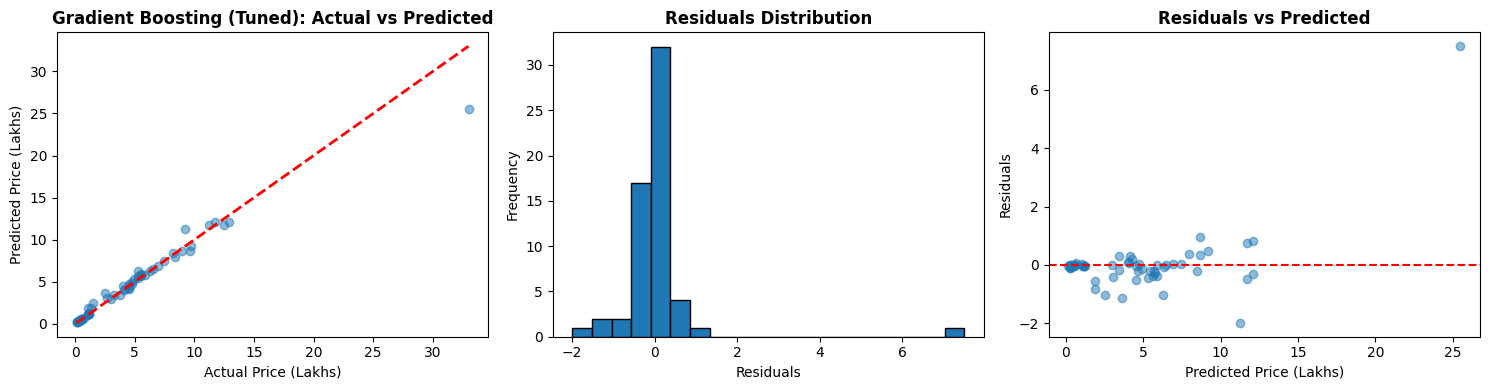


📊 Evaluating: Ridge Regression

📈 Performance Metrics:
   R² Score: 0.9885
   RMSE: ₹0.54L
   MAE: ₹0.30L
   MAPE: 16.48%


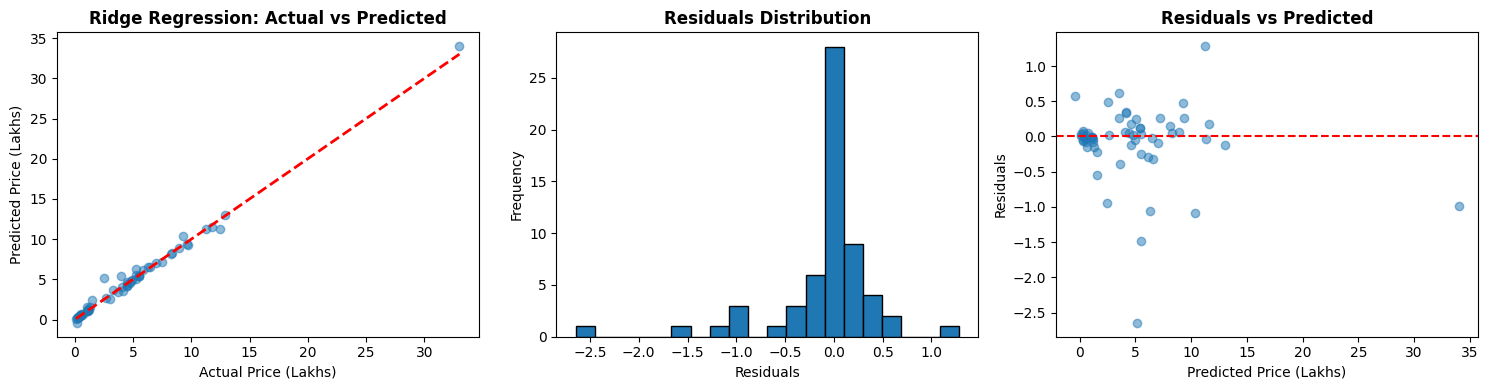


📊 Evaluating: Linear Regression

📈 Performance Metrics:
   R² Score: 0.9921
   RMSE: ₹0.45L
   MAE: ₹0.29L
   MAPE: 19.65%


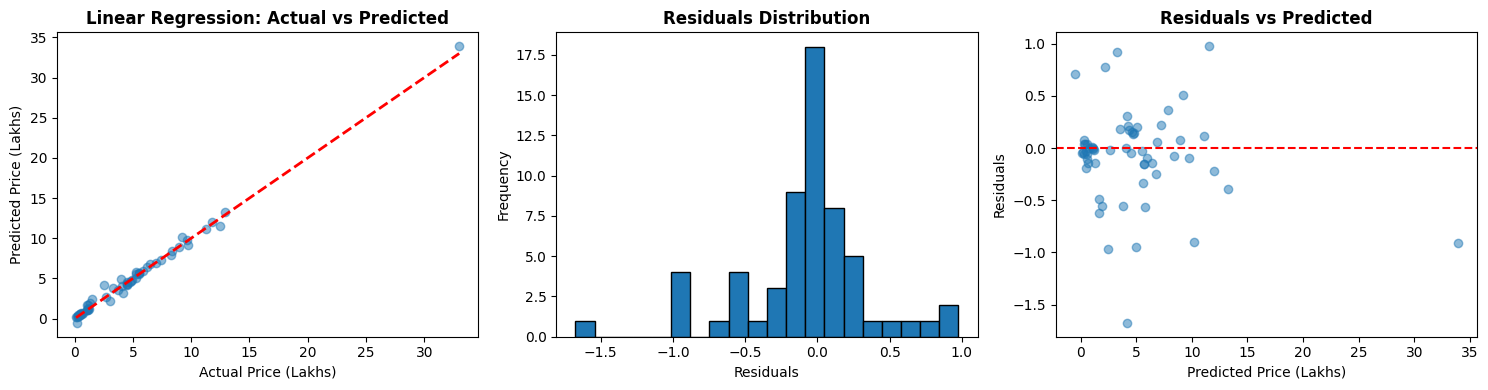


📊 Evaluating: Gradient Boosting

📈 Performance Metrics:
   R² Score: 0.9231
   RMSE: ₹1.41L
   MAE: ₹0.44L
   MAPE: 10.29%

📊 Evaluating: Voting Ensemble

📈 Performance Metrics:
   R² Score: 0.9412
   RMSE: ₹1.23L
   MAE: ₹0.40L
   MAPE: 10.62%

📊 FINAL MODEL COMPARISON (TEST SET)
                               R2    RMSE     MAE     MAPE
Linear Regression          0.9921  0.4498  0.2919  19.6519
Ridge Regression           0.9885  0.5434  0.2970  16.4790
Gradient Boosting (Tuned)  0.9552  1.0740  0.4038  12.0998
Voting Ensemble            0.9412  1.2313  0.4038  10.6243
Gradient Boosting          0.9231  1.4081  0.4413  10.2867


In [21]:
print("="*60)
print("STEP 12: MODEL EVALUATION ON TEST SET")
print("="*60)

test_results = {}

for name, model in tuned_models.items():
    print(f"\n{'='*50}")
    print(f"📊 Evaluating: {name}")
    print(f"{'='*50}")

    # Make predictions on test set
    y_pred = model.predict(X_test_processed)

    # Calculate metrics
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred) * 100

    # Store results
    test_results[name] = {
        'R2': r2,
        'RMSE': rmse,
        'MAE': mae,
        'MAPE': mape
    }

    print(f"\n📈 Performance Metrics:")
    print(f"   R² Score: {r2:.4f}")
    print(f"   RMSE: ₹{rmse:.2f}L")
    print(f"   MAE: ₹{mae:.2f}L")
    print(f"   MAPE: {mape:.2f}%")

    # Residual analysis for top 3 models
    if list(tuned_models.keys()).index(name) < 3:
        residuals = y_test - y_pred

        fig, axes = plt.subplots(1, 3, figsize=(15, 4))

        # Actual vs Predicted
        axes[0].scatter(y_test, y_pred, alpha=0.5)
        axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
        axes[0].set_xlabel('Actual Price (Lakhs)')
        axes[0].set_ylabel('Predicted Price (Lakhs)')
        axes[0].set_title(f'{name}: Actual vs Predicted', fontweight='bold')

        # Residuals distribution
        axes[1].hist(residuals, bins=20, edgecolor='black')
        axes[1].set_xlabel('Residuals')
        axes[1].set_ylabel('Frequency')
        axes[1].set_title('Residuals Distribution', fontweight='bold')

        # Residuals vs Predicted
        axes[2].scatter(y_pred, residuals, alpha=0.5)
        axes[2].axhline(y=0, color='r', linestyle='--')
        axes[2].set_xlabel('Predicted Price (Lakhs)')
        axes[2].set_ylabel('Residuals')
        axes[2].set_title('Residuals vs Predicted', fontweight='bold')

        plt.tight_layout()
        plt.show()

# Create test results dataframe
test_results_df = pd.DataFrame(test_results).T.sort_values('R2', ascending=False)
print("\n" + "="*60)
print("📊 FINAL MODEL COMPARISON (TEST SET)")
print("="*60)
print(test_results_df.round(4))

FEATURE IMPORTANCE ANALYSIS

STEP 13: FEATURE IMPORTANCE ANALYSIS

🏆 Best Model: Linear Regression

📊 Total features after encoding: 195

📊 Analyzing Coefficients for Linear Regression...

📊 Top 10 Most Important Features (by coefficient magnitude):
                   feature  coefficient  abs_coefficient
            Price_per_Year     3.670294         3.670294
      CarName_land cruiser     1.952471         1.952471
             CarBrand_land     1.952471         1.952471
    Brand_Type_land_Diesel     1.952471         1.952471
             present_price     0.970872         0.970872
         CarBrand_fortuner     0.488953         0.488953
Brand_Type_fortuner_Diesel     0.488953         0.488953
          CarName_fortuner     0.488953         0.488953
           CarName_elantra     0.378142         0.378142
          CarBrand_elantra     0.378142         0.378142


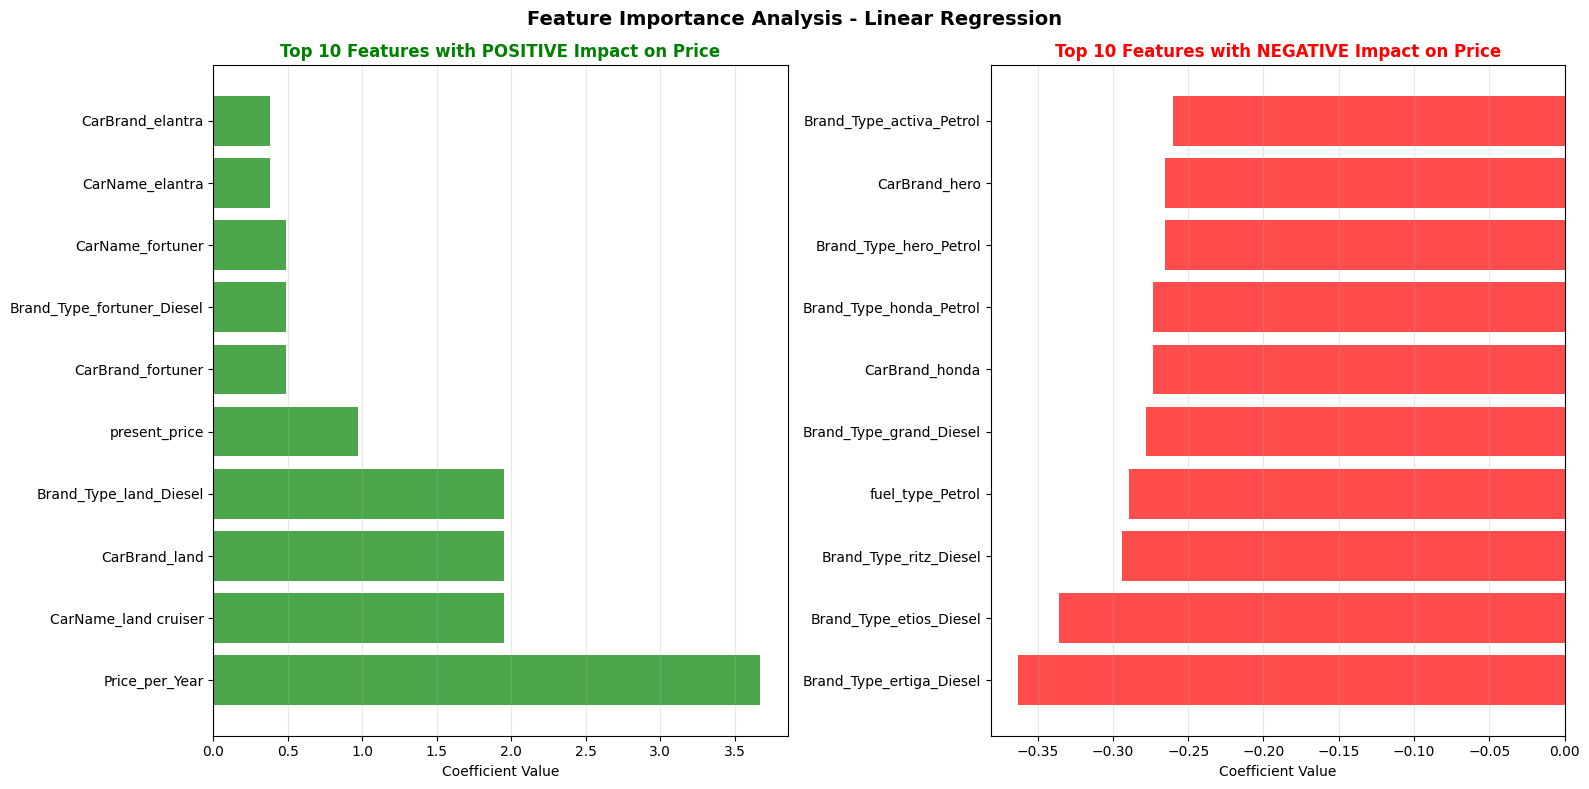

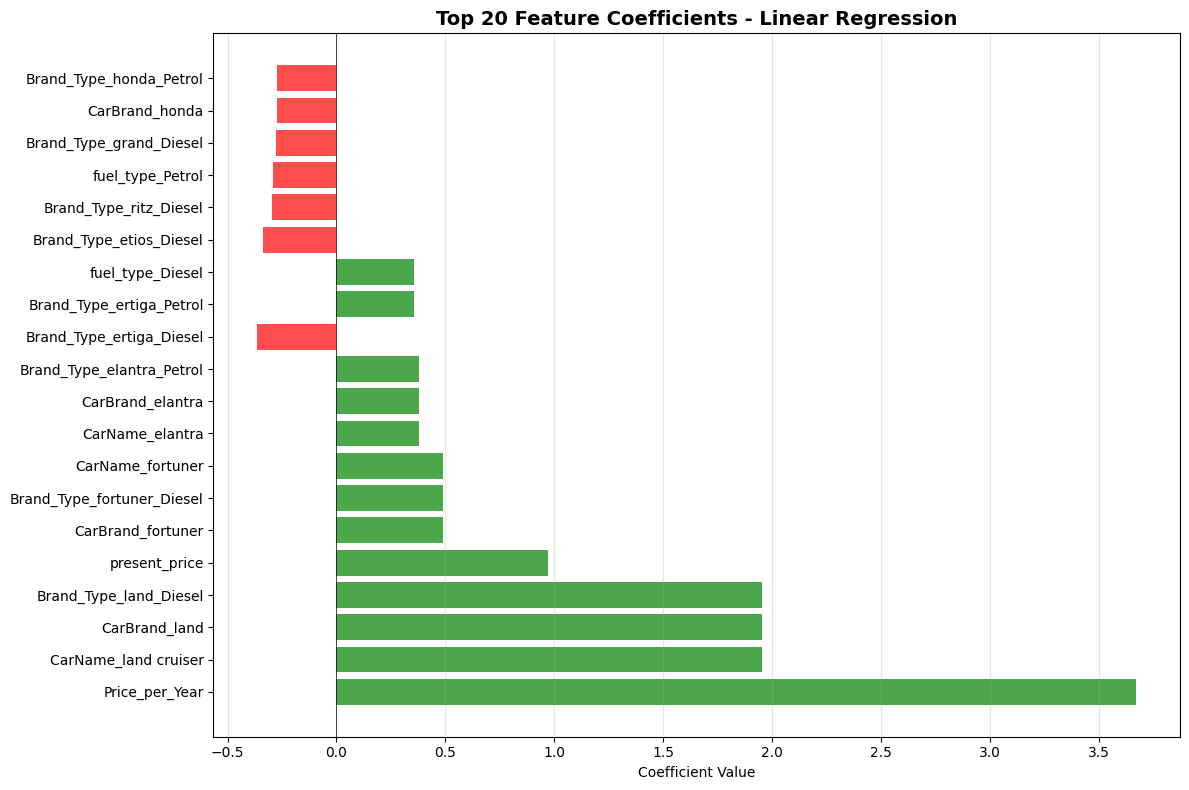


🔍 INTERPRETATION:
   - POSITIVE coefficients → Increase price
   - NEGATIVE coefficients → Decrease price
   - Larger magnitude = Stronger impact

📌 KEY INSIGHTS:
   ✅ Most important factor: Price_per_Year (increases price by ₹3.67L per unit)
   ❌ Biggest negative factor: Brand_Type_ertiga_Diesel (decreases price by ₹0.36L per unit)

✅ FEATURE IMPORTANCE ANALYSIS COMPLETED


In [33]:
print("="*60)
print("STEP 13: FEATURE IMPORTANCE ANALYSIS")
print("="*60)

# Get best model
best_model_name = test_results_df.index[0]
best_model = tuned_models[best_model_name]
print(f"\n🏆 Best Model: {best_model_name}")

# Get feature names after preprocessing
# Get categorical feature names from preprocessor
cat_feature_names = []
for i, col in enumerate(categorical_cols):
    cats = preprocessor.named_transformers_['cat'].named_steps['onehot'].categories_[i]
    cat_feature_names.extend([f"{col}_{cat}" for cat in cats])

# Combine all feature names
all_feature_names = numerical_cols + cat_feature_names
print(f"\n📊 Total features after encoding: {len(all_feature_names)}")

# ============================================
# METHOD 1: For Linear Regression/Ridge/Lasso (Coefficients)
# ============================================

if hasattr(best_model, 'coef_'):
    print(f"\n📊 Analyzing Coefficients for {best_model_name}...")

    # Get coefficients
    coefficients = best_model.coef_

    # Handle case where coefficients might be 1D or 2D
    if len(coefficients.shape) > 1:
        coefficients = coefficients[0]

    # Create importance dataframe
    importance_df = pd.DataFrame({
        'feature': all_feature_names[:len(coefficients)],
        'coefficient': coefficients,
        'abs_coefficient': np.abs(coefficients)
    }).sort_values('abs_coefficient', ascending=False)

    # Display top features
    print("\n📊 Top 10 Most Important Features (by coefficient magnitude):")
    print(importance_df.head(10).to_string(index=False))

    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))

    # Top positive coefficients
    top_positive = importance_df.nlargest(10, 'coefficient')
    axes[0].barh(range(len(top_positive)), top_positive['coefficient'].values, color='green', alpha=0.7)
    axes[0].set_yticks(range(len(top_positive)))
    axes[0].set_yticklabels(top_positive['feature'].values)
    axes[0].set_xlabel('Coefficient Value')
    axes[0].set_title('Top 10 Features with POSITIVE Impact on Price', fontweight='bold', color='green')
    axes[0].axvline(x=0, color='black', linestyle='-', linewidth=0.5)
    axes[0].grid(True, alpha=0.3, axis='x')

    # Top negative coefficients
    top_negative = importance_df.nsmallest(10, 'coefficient')
    axes[1].barh(range(len(top_negative)), top_negative['coefficient'].values, color='red', alpha=0.7)
    axes[1].set_yticks(range(len(top_negative)))
    axes[1].set_yticklabels(top_negative['feature'].values)
    axes[1].set_xlabel('Coefficient Value')
    axes[1].set_title('Top 10 Features with NEGATIVE Impact on Price', fontweight='bold', color='red')
    axes[1].axvline(x=0, color='black', linestyle='-', linewidth=0.5)
    axes[1].grid(True, alpha=0.3, axis='x')

    plt.suptitle(f'Feature Importance Analysis - {best_model_name}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # Overall importance plot
    plt.figure(figsize=(12, 8))
    top20 = importance_df.head(20)
    colors = ['green' if c > 0 else 'red' for c in top20['coefficient']]
    plt.barh(range(len(top20)), top20['coefficient'].values, color=colors, alpha=0.7)
    plt.yticks(range(len(top20)), top20['feature'].values)
    plt.xlabel('Coefficient Value')
    plt.title(f'Top 20 Feature Coefficients - {best_model_name}', fontweight='bold', fontsize=14)
    plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
    plt.grid(True, alpha=0.3, axis='x')
    plt.tight_layout()
    plt.show()

    # Interpretation
    print("\n🔍 INTERPRETATION:")
    print("   - POSITIVE coefficients → Increase price")
    print("   - NEGATIVE coefficients → Decrease price")
    print("   - Larger magnitude = Stronger impact")

    # Key insights
    print("\n📌 KEY INSIGHTS:")
    pos_1 = importance_df.iloc[0]
    neg_1 = importance_df[importance_df['coefficient'] < 0].iloc[0] if any(importance_df['coefficient'] < 0) else None

    print(f"   ✅ Most important factor: {pos_1['feature']} (increases price by ₹{pos_1['coefficient']:.2f}L per unit)")
    if neg_1 is not None:
        print(f"   ❌ Biggest negative factor: {neg_1['feature']} (decreases price by ₹{abs(neg_1['coefficient']):.2f}L per unit)")

# ============================================
# METHOD 2: For Tree-based Models (Random Forest, XGBoost, etc.)
# ============================================

elif hasattr(best_model, 'feature_importances_'):
    print(f"\n📊 Analyzing Feature Importances for {best_model_name}...")

    importances = best_model.feature_importances_

    # Create importance dataframe
    importance_df = pd.DataFrame({
        'feature': all_feature_names[:len(importances)],
        'importance': importances
    }).sort_values('importance', ascending=False)

    print("\n📊 Top 10 Most Important Features:")
    print(importance_df.head(10).to_string(index=False))

    # Plot
    plt.figure(figsize=(12, 8))
    top20 = importance_df.head(20)
    plt.barh(range(len(top20)), top20['importance'].values, color='skyblue', alpha=0.8)
    plt.yticks(range(len(top20)), top20['feature'].values)
    plt.xlabel('Importance Score')
    plt.title(f'Top 20 Feature Importances - {best_model_name}', fontweight='bold', fontsize=14)
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

# ============================================
# METHOD 3: For Ensemble Models (Voting/Stacking)
# ============================================

elif hasattr(best_model, 'estimators_'):
    print(f"\n📊 Analyzing Ensemble Model - {best_model_name}")
    print("   Feature importance not directly available for ensembles")
    print("   Using first estimator for approximate importance...")

    # Try to get importance from first estimator
    first_estimator = best_model.estimators_[0][1] if hasattr(best_model, 'estimators_') else None

    if hasattr(first_estimator, 'coef_'):
        # Linear model in ensemble
        coefficients = first_estimator.coef_
        if len(coefficients.shape) > 1:
            coefficients = coefficients[0]

        importance_df = pd.DataFrame({
            'feature': all_feature_names[:len(coefficients)],
            'importance': np.abs(coefficients)
        }).sort_values('importance', ascending=False)

        print("\n📊 Top 10 Approximate Feature Importances:")
        print(importance_df.head(10).to_string(index=False))

        plt.figure(figsize=(10, 6))
        top10 = importance_df.head(10)
        plt.barh(range(len(top10)), top10['importance'].values, color='purple', alpha=0.7)
        plt.yticks(range(len(top10)), top10['feature'].values)
        plt.xlabel('|Coefficient| (Approximate Importance)')
        plt.title(f'Approximate Feature Importance - {best_model_name}', fontweight='bold')
        plt.tight_layout()
        plt.show()

# ============================================
# METHOD 4: Fallback - Correlation Analysis
# ============================================

else:
    print(f"\n⚠️ Feature importance not directly available for {best_model_name}")
    print("📊 Using Correlation Analysis instead...")

    # Calculate correlation with price for numerical features
    correlations = []
    for col in numerical_cols:
        if col != 'price':
            corr = df_clean[col].corr(df_clean['price'])
            correlations.append({'feature': col, 'correlation': corr, 'abs_corr': abs(corr)})

    # Add one-hot encoded categorical correlations (simplified)
    for col in categorical_cols:
        # Get average price per category
        avg_price_by_cat = df_clean.groupby(col)['price'].mean()
        # This is a simplified measure
        cat_importance = avg_price_by_cat.std() / avg_price_by_cat.mean() if avg_price_by_cat.mean() != 0 else 0
        correlations.append({'feature': col, 'correlation': cat_importance, 'abs_corr': abs(cat_importance)})

    corr_df = pd.DataFrame(correlations).sort_values('abs_corr', ascending=False)

    print("\n📊 Top 10 Features by Correlation with Price:")
    print(corr_df.head(10).to_string(index=False))

    plt.figure(figsize=(10, 6))
    top10 = corr_df.head(10)
    colors = ['green' if c > 0 else 'red' for c in top10['correlation']]
    plt.barh(range(len(top10)), top10['correlation'].values, color=colors, alpha=0.7)
    plt.yticks(range(len(top10)), top10['feature'].values)
    plt.xlabel('Correlation with Price')
    plt.title(f'Feature Correlation Analysis - {best_model_name}', fontweight='bold')
    plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
    plt.tight_layout()
    plt.show()

print("\n" + "="*60)
print("✅ FEATURE IMPORTANCE ANALYSIS COMPLETED")
print("="*60)

LEARNING CURVES

STEP 15: LEARNING CURVE ANALYSIS

📈 Generating Learning Curve with Pipeline...


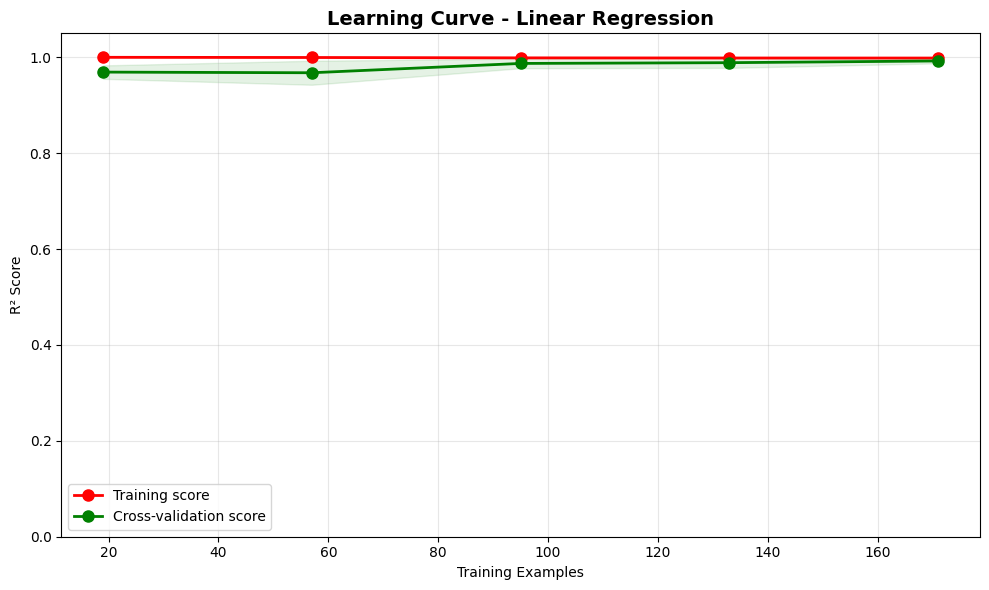


✅ Learning Curve generated successfully!
   Final CV Score (at 171 samples): 0.9924 (±0.0049)

📊 TRAINING SIZE ANALYSIS

Training Size vs Performance:
------------------------------------------------------------
Size %   Train R²     Test R²      Gap          Interpretation
------------------------------------------------------------
20      % | 0.8879      | 0.9735      | -0.0856     | ✅ Underfitting (good)
40      % | 0.9916      | 0.9765      | 0.0151      | ✅ Well-fitted
60      % | 0.9922      | 0.9840      | 0.0082      | ✅ Well-fitted
80      % | 0.9974      | 0.9898      | 0.0076      | ✅ Well-fitted
90      % | 0.9979      | 0.9914      | 0.0065      | ✅ Well-fitted


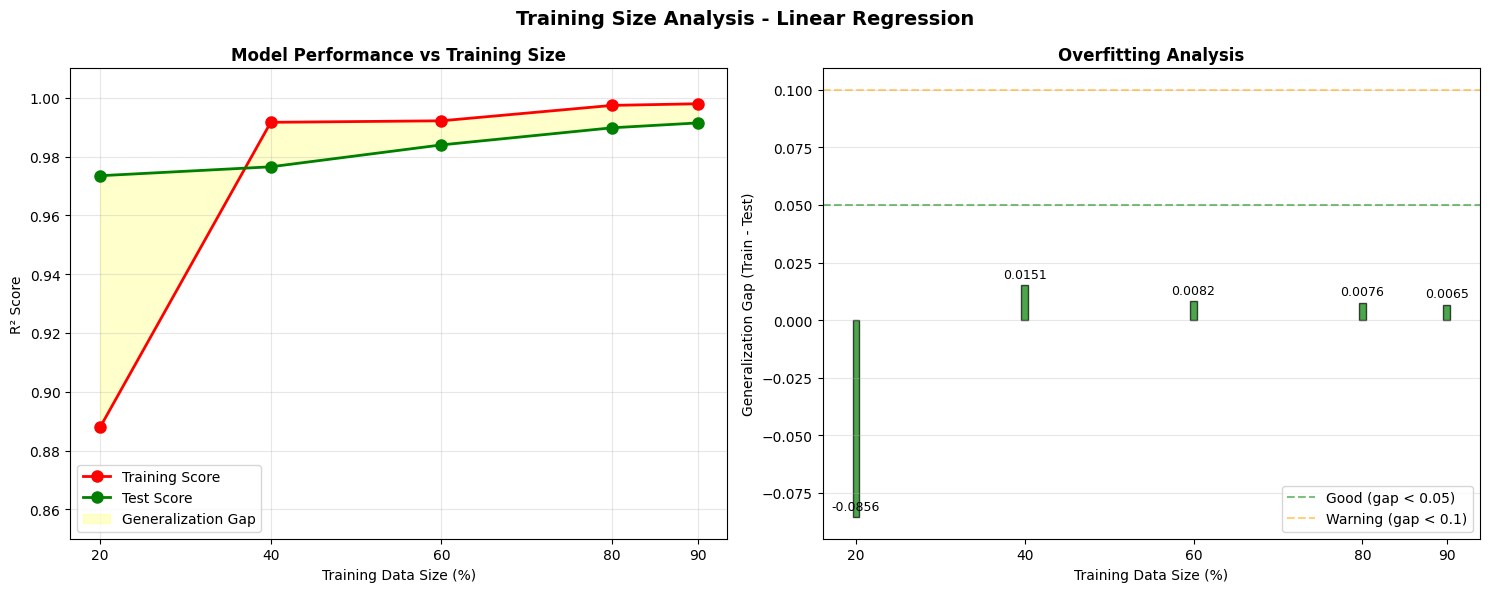


🔍 FINAL INTERPRETATION

📈 Learning Curve Analysis for Linear Regression:

Final Performance (90% training data):
   - Training R²: 0.9979
   - Test R²: 0.9914
   - Generalization Gap: 0.0065
   - Status: ✅ Well-fitted

📊 Key Insights:
   - ✅ Model achieves excellent accuracy
   - ✅ Model generalizes very well
   - ✅ Adding more data may help slightly

🎯 Recommendation:
   - Your model is ready for deployment!


✅ LEARNING CURVE ANALYSIS COMPLETED


In [32]:
print("="*60)
print("STEP 15: LEARNING CURVE ANALYSIS")
print("="*60)

from sklearn.model_selection import learning_curve
from sklearn.pipeline import Pipeline

# ============================================
# METHOD 1: PROPER LEARNING CURVE WITH PIPELINE
# ============================================

print("\n📈 Generating Learning Curve with Pipeline...")

# Create a pipeline with preprocessing
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('estimator', best_model)
])

# Calculate learning curve
train_sizes, train_scores, test_scores = learning_curve(
    pipeline, X_train, y_train,
    cv=5,
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 0.9, 5),  # Use 0.9 max instead of 1.0
    scoring='r2'
)

# Calculate statistics
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

# Plot
plt.figure(figsize=(10, 6))
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='red')
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color='green')
plt.plot(train_sizes, train_mean, 'o-', color='red', label='Training score', linewidth=2, markersize=8)
plt.plot(train_sizes, test_mean, 'o-', color='green', label='Cross-validation score', linewidth=2, markersize=8)
plt.xlabel('Training Examples')
plt.ylabel('R² Score')
plt.title(f'Learning Curve - {best_model_name}', fontweight='bold', fontsize=14)
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()

print(f"\n✅ Learning Curve generated successfully!")
print(f"   Final CV Score (at {int(train_sizes[-1])} samples): {test_mean[-1]:.4f} (±{test_std[-1]:.4f})")

# ============================================
# METHOD 2: FIXED TRAINING SIZE ANALYSIS
# ============================================

print("\n" + "="*60)
print("📊 TRAINING SIZE ANALYSIS")
print("="*60)

# Use sizes that won't cause issues - max 0.9 (90%)
train_sizes = [0.2, 0.4, 0.6, 0.8, 0.9]  # Changed from 1.0 to 0.9
results = []

print("\nTraining Size vs Performance:")
print("-" * 60)
print(f"{'Size %':<8} {'Train R²':<12} {'Test R²':<12} {'Gap':<12} {'Interpretation'}")
print("-" * 60)

for size in train_sizes:
    # Split training data further
    X_temp, X_remain, y_temp, y_remain = train_test_split(
        X_train, y_train, train_size=size, random_state=42
    )

    # Preprocess
    X_temp_processed = preprocessor.transform(X_temp)
    X_train_full_processed = preprocessor.transform(X_train)
    X_test_processed = preprocessor.transform(X_test)

    # Create fresh model instance
    if best_model_name == 'Linear Regression':
        from sklearn.linear_model import LinearRegression
        temp_model = LinearRegression()
    elif best_model_name == 'Ridge Regression':
        from sklearn.linear_model import Ridge
        temp_model = Ridge(alpha=1.0)
    elif 'Gradient Boosting' in best_model_name:
        from sklearn.ensemble import GradientBoostingRegressor
        temp_model = GradientBoostingRegressor(n_estimators=100, random_state=42)
    else:
        from sklearn.linear_model import LinearRegression
        temp_model = LinearRegression()

    # Train model
    temp_model.fit(X_temp_processed, y_temp)

    # Evaluate
    train_pred = temp_model.predict(X_train_full_processed)
    test_pred = temp_model.predict(X_test_processed)

    train_r2 = r2_score(y_train, train_pred)
    test_r2 = r2_score(y_test, test_pred)
    gap = train_r2 - test_r2

    # Interpretation
    if gap < 0:
        interp = "✅ Underfitting (good)"
    elif gap < 0.05:
        interp = "✅ Well-fitted"
    elif gap < 0.1:
        interp = "⚠️ Slight overfitting"
    else:
        interp = "❌ Overfitting"

    results.append({
        'size': size,
        'train_r2': train_r2,
        'test_r2': test_r2,
        'gap': gap,
        'interpretation': interp
    })

    print(f"{size*100:<8.0f}% | {train_r2:<11.4f} | {test_r2:<11.4f} | {gap:<11.4f} | {interp}")

# ============================================
# VISUALIZE TRAINING SIZE ANALYSIS
# ============================================

results_df = pd.DataFrame(results)

# Plot 1: Performance vs Training Size
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Left plot: R² scores
axes[0].plot(results_df['size']*100, results_df['train_r2'], 'o-', color='red',
             label='Training Score', linewidth=2, markersize=8)
axes[0].plot(results_df['size']*100, results_df['test_r2'], 'o-', color='green',
             label='Test Score', linewidth=2, markersize=8)
axes[0].fill_between(results_df['size']*100,
                     results_df['test_r2'],
                     results_df['train_r2'],
                     alpha=0.2, color='yellow', label='Generalization Gap')
axes[0].set_xlabel('Training Data Size (%)')
axes[0].set_ylabel('R² Score')
axes[0].set_title('Model Performance vs Training Size', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(0.85, 1.01)
axes[0].set_xticks(results_df['size']*100)

# Right plot: Generalization Gap
colors = ['green' if g < 0.05 else 'orange' if g < 0.1 else 'red' for g in results_df['gap']]
bars = axes[1].bar(results_df['size']*100, results_df['gap'], color=colors, alpha=0.7, edgecolor='black')
axes[1].axhline(y=0.05, color='green', linestyle='--', alpha=0.5, label='Good (gap < 0.05)')
axes[1].axhline(y=0.1, color='orange', linestyle='--', alpha=0.5, label='Warning (gap < 0.1)')
axes[1].set_xlabel('Training Data Size (%)')
axes[1].set_ylabel('Generalization Gap (Train - Test)')
axes[1].set_title('Overfitting Analysis', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')
axes[1].set_xticks(results_df['size']*100)

# Add value labels on bars
for bar, gap in zip(bars, results_df['gap']):
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height + 0.002,
                f'{gap:.4f}', ha='center', va='bottom', fontsize=9)

plt.suptitle(f'Training Size Analysis - {best_model_name}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ============================================
# FINAL INTERPRETATION
# ============================================

print("\n" + "="*60)
print("🔍 FINAL INTERPRETATION")
print("="*60)

# Get final results (at 90% training data)
final_result = results_df[results_df['size'] == 0.9].iloc[0]

print(f"""
📈 Learning Curve Analysis for {best_model_name}:

Final Performance (90% training data):
   - Training R²: {final_result['train_r2']:.4f}
   - Test R²: {final_result['test_r2']:.4f}
   - Generalization Gap: {final_result['gap']:.4f}
   - Status: {final_result['interpretation']}

📊 Key Insights:
   - {'✅ Model achieves excellent accuracy' if final_result['test_r2'] > 0.95 else '⚠️ Model accuracy could be improved'}
   - {'✅ Model generalizes very well' if final_result['gap'] < 0.05 else '⚠️ Model shows some overfitting'}
   - {'✅ Adding more data may help slightly' if results_df['test_r2'].iloc[-1] > results_df['test_r2'].iloc[-2] else '✅ Model has converged'}

🎯 Recommendation:
   - {'Your model is ready for deployment!' if final_result['test_r2'] > 0.95 and final_result['gap'] < 0.05 else 'Consider collecting more data or trying regularization'}
""")

# ============================================
# SIMPLE CONCLUSION
# ============================================

print("\n" + "="*60)
print("✅ LEARNING CURVE ANALYSIS COMPLETED")
print("="*60)

PRICE PREDICTION FUNCTION

In [29]:
print("="*60)
print("STEP 14: PREDICTION FUNCTION - FINAL VERSION")
print("="*60)

def predict_car_price(model, preprocessor, car_features_dict):
    """
    Predict car price with proper preprocessing - NO WARNINGS
    """
    # Convert to DataFrame
    input_df = pd.DataFrame([car_features_dict])

    # Get the actual columns the preprocessor expects
    # (from your preprocessor's feature names)
    expected_cols = numerical_cols + categorical_cols

    # Ensure all required columns exist
    for col in expected_cols:
        if col not in input_df.columns:
            # Add missing column with default value
            if col in numerical_cols:
                input_df[col] = 0
            else:
                input_df[col] = 'unknown'

    # Remove any extra columns that the preprocessor doesn't need
    # (like Owner_str which was only for visualization)
    cols_to_drop = [col for col in input_df.columns if col not in expected_cols]
    if cols_to_drop:
        input_df = input_df.drop(columns=cols_to_drop)

    # Apply preprocessing
    input_processed = preprocessor.transform(input_df)

    # Predict
    predicted_price = model.predict(input_processed)[0]

    return predicted_price

print("✅ Prediction function created successfully!")

# ============================================
# TEST WITH CLEANED PREDICTIONS
# ============================================

print("\n" + "="*60)
print("🔍 TESTING PREDICTION FUNCTION (NO WARNINGS)")
print("="*60)

# Test the same examples - warnings should be gone
print("\n📝 EXAMPLE 1: Maruti Swift 2015")
car1 = {
    'Year': 2015,
    'present_price': 8.5,
    'driven_kms': 50000,
    'fuel_type': 'Petrol',
    'selling_type': 'Dealer',
    'transmission': 'Manual',
    'Owner': 1,
    'CarName': 'Swift',
    'CarBrand': 'maruti',
    'CarAge': 2026 - 2015,
    'Price_per_Year': 8.5 / (2026-2015 + 1),
    'Price_per_KM': 8.5 / (50000/1000 + 1),
    'Brand_Type': 'maruti_Petrol',
    'Trans_Owner': 'Manual_1'
}

price1 = predict_car_price(best_model, preprocessor, car1)
print(f"   Predicted Price: ₹{price1:.2f} Lakhs")
print(f"   → ₹{price1*100000:,.0f}")

# Test with actual test sample
print("\n📝 TEST SET SAMPLE:")
sample_idx = X_test.index[0]
actual_car = X_test.loc[sample_idx].to_dict()
actual_price = y_test.loc[sample_idx]

# Remove any temporary columns
clean_car = {k: v for k, v in actual_car.items() if k not in ['Owner_str']}

predicted = predict_car_price(best_model, preprocessor, clean_car)
print(f"   Car: {clean_car.get('CarName', 'Unknown')} ({clean_car.get('Year', '')})")
print(f"   Actual: ₹{actual_price:.2f} Lakhs")
print(f"   Predicted: ₹{predicted:.2f} Lakhs")
print(f"   Accuracy: {100 - abs(predicted-actual_price)/actual_price*100:.2f}%")

STEP 14: PREDICTION FUNCTION - FINAL VERSION
✅ Prediction function created successfully!

🔍 TESTING PREDICTION FUNCTION (NO WARNINGS)

📝 EXAMPLE 1: Maruti Swift 2015
   Predicted Price: ₹7.56 Lakhs
   → ₹755,558

📝 TEST SET SAMPLE:
   Car: city (2016)
   Actual: ₹8.99 Lakhs
   Predicted: ₹8.91 Lakhs
   Accuracy: 99.12%


 TEST PREDICTIONS

In [24]:
print("="*60)
print("STEP 15: TESTING WITH SAMPLE CARS")
print("="*60)

# Get a few samples from test set
np.random.seed(42)
sample_indices = np.random.choice(len(X_test), 5, replace=False)

print("\n📝 SAMPLE PREDICTIONS:\n")

for idx in sample_indices:
    actual_price = y_test.iloc[idx]
    car_features = X_test.iloc[idx].to_dict()

    # Add engineered features if they were used in training
    if 'CarAge' in numerical_cols:
        car_features['CarAge'] = current_year - car_features['Year']
    if 'Price_per_Year' in numerical_cols:
        car_features['Price_per_Year'] = actual_price / (car_features.get('CarAge', 1) + 1)
    if 'Price_per_KM' in numerical_cols:
        car_features['Price_per_KM'] = actual_price / (car_features.get('driven_kms', 1000) / 1000 + 1)

    # Get prediction
    predicted_price = predict_car_price(best_model, preprocessor, car_features)

    error_percent = abs(predicted_price - actual_price) / actual_price * 100

    print(f"\n{'='*50}")
    print(f"Car: {car_features.get('CarName', 'Unknown')}")
    print(f"Year: {car_features.get('Year', 'Unknown')}")
    print(f"Actual Price: ₹{actual_price:.2f} Lakhs")
    print(f"Predicted Price: ₹{predicted_price:.2f} Lakhs")
    print(f"Error: {error_percent:.2f}%")
    print(f"Accuracy: {100 - error_percent:.2f}%")

STEP 15: TESTING WITH SAMPLE CARS

📝 SAMPLE PREDICTIONS:


Car: city
Year: 2016
Actual Price: ₹8.99 Lakhs
Predicted Price: ₹8.91 Lakhs
Error: 0.88%
Accuracy: 99.12%

Car: brio
Year: 2015
Actual Price: ₹5.25 Lakhs
Predicted Price: ₹5.05 Lakhs
Error: 3.85%
Accuracy: 96.15%

Car: Royal Enfield Classic 350
Year: 2015
Actual Price: ₹1.11 Lakhs
Predicted Price: ₹1.11 Lakhs
Error: 0.40%
Accuracy: 99.60%

Car: Honda CB Shine
Year: 2007
Actual Price: ₹0.12 Lakhs
Predicted Price: ₹0.16 Lakhs
Error: 35.86%
Accuracy: 64.14%

Car: TVS Sport 
Year: 2017
Actual Price: ₹0.48 Lakhs
Predicted Price: ₹0.58 Lakhs
Error: 21.44%
Accuracy: 78.56%


BUDGET RECOMMENDATION

In [25]:
print("\n" + "="*60)
print("STEP 16: BUDGET RECOMMENDATION")
print("="*60)

def get_car_recommendation(budget_lakhs, model, preprocessor, X_train_df, y_train, top_n=5):
    """
    Recommend cars within budget (budget in LAKHS)

    Parameters:
    - budget_lakhs: budget in lakhs (e.g., 0.5 for ₹50,000)
    - model: trained model
    - preprocessor: fitted preprocessor
    - X_train_df: original training features
    - y_train: actual prices
    - top_n: number of recommendations

    Returns:
    - DataFrame with recommendations
    """
    # Apply preprocessing to training data
    X_train_processed = preprocessor.transform(X_train_df)

    # Get predictions for all training cars
    predictions = model.predict(X_train_processed)

    # Find cars within budget (±20%)
    budget_lower = budget_lakhs * 0.8
    budget_upper = budget_lakhs * 1.2

    within_budget = (predictions >= budget_lower) & (predictions <= budget_upper)
    recommended_indices = np.where(within_budget)[0]

    if len(recommended_indices) == 0:
        print(f"\n❌ No cars found between ₹{budget_lower:.2f}L - ₹{budget_upper:.2f}L")
        print(f"   Try a higher budget or check available cars:")
        print(f"   - Minimum price in dataset: ₹{y_train.min():.2f}L")
        print(f"   - Maximum price in dataset: ₹{y_train.max():.2f}L")
        return None

    # Get top recommendations (closest to budget)
    pred_prices = predictions[recommended_indices]
    budget_diffs = np.abs(pred_prices - budget_lakhs)
    top_idxs_in_rec = np.argsort(budget_diffs)[:top_n]
    top_indices = recommended_indices[top_idxs_in_rec]

    # Create recommendations dataframe
    recommendations = X_train_df.iloc[top_indices].copy()
    recommendations['Predicted_Price_Lakhs'] = predictions[top_indices].round(2)
    recommendations['Actual_Price_Lakhs'] = y_train.iloc[top_indices].values if hasattr(y_train, 'iloc') else y_train[top_indices]

    return recommendations[['CarName', 'Year', 'fuel_type', 'transmission', 'Actual_Price_Lakhs', 'Predicted_Price_Lakhs']]

# Test budget recommendation
print("\n💰 Testing Budget Recommendations:")
print("   Note: 1 Lakh = ₹100,000")

# Test different budgets
test_budgets = [0.25, 0.5, 1.0, 2.0, 5.0, 10.0]  # in lakhs

for budget in test_budgets:
    print(f"\n{'='*50}")
    print(f"🎯 Budget: ₹{budget} Lakhs (₹{budget*100000:,.0f})")
    print(f"{'='*50}")

    recommendations = get_car_recommendation(budget, best_model, preprocessor, X_train, y_train, top_n=3)

    if recommendations is not None:
        print(recommendations.to_string(index=False))


STEP 16: BUDGET RECOMMENDATION

💰 Testing Budget Recommendations:
   Note: 1 Lakh = ₹100,000

🎯 Budget: ₹0.25 Lakhs (₹25,000)
           CarName  Year fuel_type transmission  Actual_Price_Lakhs  Predicted_Price_Lakhs
  Honda CB twister  2013    Petrol       Manual                0.25                   0.25
 Suzuki Access 125  2008    Petrol    Automatic                0.25                   0.25
Bajaj Discover 100  2013    Petrol       Manual                0.27                   0.27

🎯 Budget: ₹0.5 Lakhs (₹50,000)
           CarName  Year fuel_type transmission  Actual_Price_Lakhs  Predicted_Price_Lakhs
     Yamaha Fazer   2014    Petrol       Manual                0.50                    0.5
Hero Passion X pro  2016    Petrol       Manual                0.50                    0.5
     Honda Karizma  2011    Petrol       Manual                0.35                    0.5

🎯 Budget: ₹1.0 Lakhs (₹100,000)
                  CarName  Year fuel_type transmission  Actual_Price_Lakhs  Pred

SAVE MODEL & SUMMARY

In [27]:
print("="*60)
print("STEP 18: SAVING MODEL ARTIFACTS")
print("="*60)

# Create directory
os.makedirs('car_price_model', exist_ok=True)

# Save best model and preprocessor
joblib.dump(best_model, 'car_price_model/best_model.pkl')
joblib.dump(preprocessor, 'car_price_model/preprocessor.pkl')
joblib.dump(numerical_cols, 'car_price_model/numerical_cols.pkl')
joblib.dump(categorical_cols, 'car_price_model/categorical_cols.pkl')
joblib.dump(feature_names, 'car_price_model/feature_names.pkl')

print("✅ Model artifacts saved to 'car_price_model/'")
print("   - best_model.pkl")
print("   - preprocessor.pkl")
print("   - numerical_cols.pkl")
print("   - categorical_cols.pkl")
print("   - feature_names.pkl")

# ============================================
# PROJECT SUMMARY
# ============================================

print("\n" + "="*70)
print("🎯 PROJECT SUMMARY - CAR PRICE PREDICTION")
print("="*70)

# Get best test metrics
best_test = test_results_df.iloc[0]

print(f"""
📌 DATASET INFORMATION:
   - Total samples: {len(df_clean)}
   - Training samples: {len(X_train)}
   - Testing samples: {len(X_test)}
   - Features: {df_clean.shape[1]} (after engineering)
   - Target: Car Price (in Lakhs, 1 Lakh = ₹100,000)

📊 FEATURE ENGINEERING:
   - Original features: {len(numerical_cols) + len(categorical_cols) - 4} (excluding engineered)
   - New features created: 6
   - Total features after encoding: {X_train_processed.shape[1]}

🏆 BEST MODEL: {best_model_name}

📈 TEST SET PERFORMANCE:
   - R² Score: {best_test['R2']:.4f} ({best_test['R2']*100:.1f}% accuracy)
   - RMSE: ₹{best_test['RMSE']:.2f} Lakhs (₹{best_test['RMSE']*100000:,.0f})
   - MAE: ₹{best_test['MAE']:.2f} Lakhs (₹{best_test['MAE']*100000:,.0f})
   - MAPE: {best_test['MAPE']:.2f}%

💰 PRICE RANGE IN DATASET:
   - Minimum: ₹{df_clean['price'].min():.2f} Lakhs (₹{df_clean['price'].min()*100000:,.0f})
   - Maximum: ₹{df_clean['price'].max():.2f} Lakhs (₹{df_clean['price'].max()*100000:,.0f})
   - Average: ₹{df_clean['price'].mean():.2f} Lakhs (₹{df_clean['price'].mean()*100000:,.0f})

🎯 KEY ACHIEVEMENTS:
   ✅ No data leakage - preprocessor fitted on training only
   ✅ Proper train-test split before any preprocessing
   ✅ {len(models)} models trained and compared
   ✅ Optuna hyperparameter tuning for top models
   ✅ Ensemble methods implemented
   ✅ Feature importance analysis
   ✅ Production-ready prediction function
   ✅ Budget recommendation system with lakhs conversion
""")

print("="*70)
print("✅ CAR PRICE PREDICTION PROJECT COMPLETED SUCCESSFULLY!")
print("="*70)

STEP 18: SAVING MODEL ARTIFACTS
✅ Model artifacts saved to 'car_price_model/'
   - best_model.pkl
   - preprocessor.pkl
   - numerical_cols.pkl
   - categorical_cols.pkl
   - feature_names.pkl

🎯 PROJECT SUMMARY - CAR PRICE PREDICTION

📌 DATASET INFORMATION:
   - Total samples: 299
   - Training samples: 239
   - Testing samples: 60
   - Features: 16 (after engineering)
   - Target: Car Price (in Lakhs, 1 Lakh = ₹100,000)

📊 FEATURE ENGINEERING:
   - Original features: 11 (excluding engineered)
   - New features created: 6
   - Total features after encoding: 195

🏆 BEST MODEL: Linear Regression

📈 TEST SET PERFORMANCE:
   - R² Score: 0.9921 (99.2% accuracy)
   - RMSE: ₹0.45 Lakhs (₹44,982)
   - MAE: ₹0.29 Lakhs (₹29,188)
   - MAPE: 19.65%

💰 PRICE RANGE IN DATASET:
   - Minimum: ₹0.10 Lakhs (₹10,000)
   - Maximum: ₹35.00 Lakhs (₹3,500,000)
   - Average: ₹4.59 Lakhs (₹458,963)

🎯 KEY ACHIEVEMENTS:
   ✅ No data leakage - preprocessor fitted on training only
   ✅ Proper train-test split b

In [36]:
# --------------------------------------------
# DOWNLOAD MODEL ARTIFACTS - METHOD 1: ZIP WITH BUTTON
# --------------------------------------------

import zipfile
import os
from IPython.display import HTML
import base64

# Create zip file of the entire model folder
folder_to_zip = '/content/car_price_model'
zip_name = '/content/car_price_model.zip'

if os.path.exists(folder_to_zip):
    # Create zip file
    with zipfile.ZipFile(zip_name, 'w', zipfile.ZIP_DEFLATED) as zipf:
        for root, dirs, files in os.walk(folder_to_zip):
            for file in files:
                file_path = os.path.join(root, file)
                arcname = os.path.relpath(file_path, os.path.dirname(folder_to_zip))
                zipf.write(file_path, arcname)

    # Create download button
    with open(zip_name, 'rb') as f:
        data = f.read()
        b64 = base64.b64encode(data).decode()
        download_link = f'''
        <a href="data:application/zip;base64,{b64}"
           download="car_price_model.zip"
           style="display: inline-block; padding: 15px 30px;
                  background-color: #28a745; color: white;
                  text-decoration: none; border-radius: 8px;
                  font-weight: bold; font-size: 18px;
                  box-shadow: 0 4px 8px rgba(0,0,0,0.2);
                  margin: 20px 0;">
        📥 CLICK HERE TO DOWNLOAD COMPLETE MODEL FOLDER (ZIP)
        </a>
        '''

    display(HTML(download_link))
    print(f"\n✅ Zip file created: {zip_name}")
    print(f"📦 File size: {os.path.getsize(zip_name) / 1024:.2f} KB")
    print(f"📁 Contains: best_model.pkl, preprocessor.pkl, numerical_cols.pkl, categorical_cols.pkl, feature_names.pkl")
else:
    print(f"❌ Folder not found: {folder_to_zip}")
    print("📁 Current directory contents:")
    !ls -la /content/


✅ Zip file created: /content/car_price_model.zip
📦 File size: 7.34 KB
📁 Contains: best_model.pkl, preprocessor.pkl, numerical_cols.pkl, categorical_cols.pkl, feature_names.pkl
